In [203]:
from enum import Enum

import numpy as np
import pandas as pd
import seaborn as sns
import pygame
from scipy.special import softmax
import scipy
import statsmodels.api as sm
import statsmodels.formula.api as smf

import gymnasium as gym
from gymnasium import spaces

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

from scipy.sparse.csgraph import shortest_path

import networkx as nx
from collections import defaultdict, Counter
import itertools
import warnings
warnings.filterwarnings("ignore")

In [2]:
# plotting params

mpl.rcParams.update({
    # Figure
    'figure.figsize': (6, 4),
    'figure.dpi': 100,
    'savefig.dpi': 300,

    # Fonts
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,

    # Axes
    'axes.linewidth': 1,
    'axes.grid': False,

    # Ticks
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.major.width': 1,
    'ytick.major.width': 1,
    'xtick.direction': 'out',
    'ytick.direction': 'out',

    # Lines
    'lines.linewidth': 2,
    'lines.markersize': 6,

    # Legend
    'legend.frameon': False,

    # Saving
    'savefig.bbox': 'tight'
})

# Data

### Load data

In [209]:
date = '20260612'
beh = pd.read_csv(f'D:/Newworld/London_{date}.csv')
beh = beh[(beh.Session<260612)]
beh['target'] = beh.target_room - 1
beh['start'] = beh.start_room - 1
beh['current'] = beh.current_room - 1

nav = beh[beh.start!=beh.target].copy()
nav['success'] = (nav['TrialError'] == 0) * 1
room_seq = nav.groupby(['Session','Trial','target','start'])['current'].agg(list).reset_index(name='rooms')

nav_trial = nav[nav.step==1].copy()
flash_trial = beh[beh.start==beh.target].copy()

nav_trial = nav_trial.merge(room_seq,on=['Session','Trial','target','start'])
nav_trial['detour_index'] = nav_trial['minus_step'] / nav_trial['graph_distance']
nav['duration'] = nav['exit']-nav['enter']

### Create graph G

In [80]:
edges = [
    (1,2), (2,3), (2,6), (3,4), (4,8),
    (5,9), (6,7), (6,10), (7,8), (7,11),
    (8,12), (9,10), (9,13), (10,11), (10,14),
    (11,15), (14,15), (15,16)
]

G = nx.Graph()
G.add_edges_from((u-1, v-1) for u, v in edges)  # 0-based indexing

### Basic quantifications

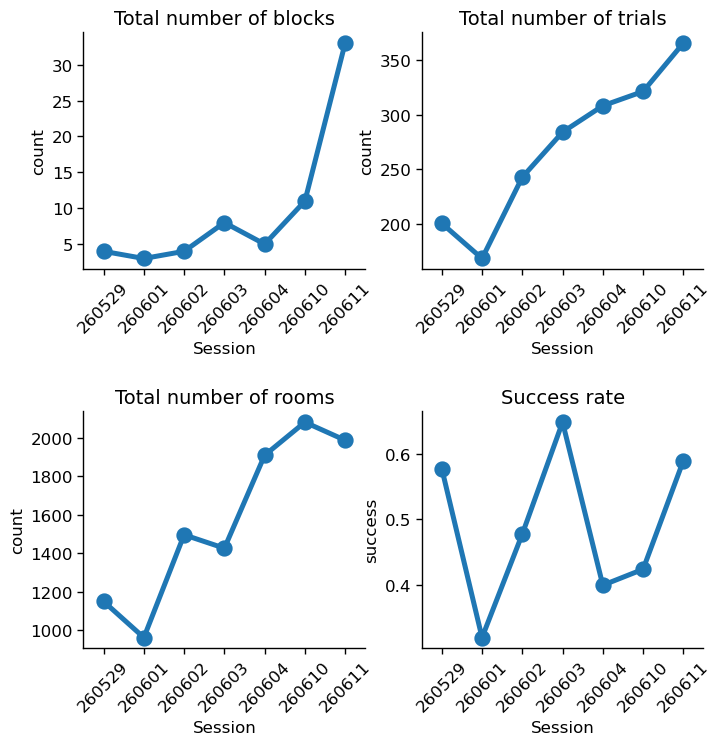

In [23]:
plt.close('all')
fig, axes = plt.subplots(2,2,figsize=(8,8),gridspec_kw={'wspace': 0.2, 'hspace': 0.6})

ax = axes[0,0]
df = nav.drop_duplicates(['Session', 'BlockNumber']).copy().groupby(['Session']).size().rename('count').reset_index()
sns.pointplot(data=df,x='Session',y='count',ax=ax)
ax.set_title('Total number of blocks')
ax.tick_params(axis='x', labelrotation=45)

ax = axes[0,1]
df = nav_trial.groupby(['Session']).size().rename('count').reset_index()
sns.pointplot(data=df,x='Session',y='count',ax=ax)
ax.set_title('Total number of trials')
ax.tick_params(axis='x', labelrotation=45)

ax = axes[1,0]
df = nav.groupby(['Session']).size().rename('count').reset_index()
sns.pointplot(data=df,x='Session',y='count',ax=ax)
ax.set_title('Total number of rooms')
ax.tick_params(axis='x', labelrotation=45)

ax = axes[1,1]
df = nav_trial.groupby(['Session']).success.mean().reset_index()
sns.pointplot(data=df,x='Session',y='success',ax=ax)
ax.set_title('Success rate')
ax.tick_params(axis='x', labelrotation=45)

sns.despine()
plt.savefig(f'{date} basic quantifications.png')

### Trial level performance

#### Success rate as a function of distance and degree

Text(0.5, 1, 'Success rate')

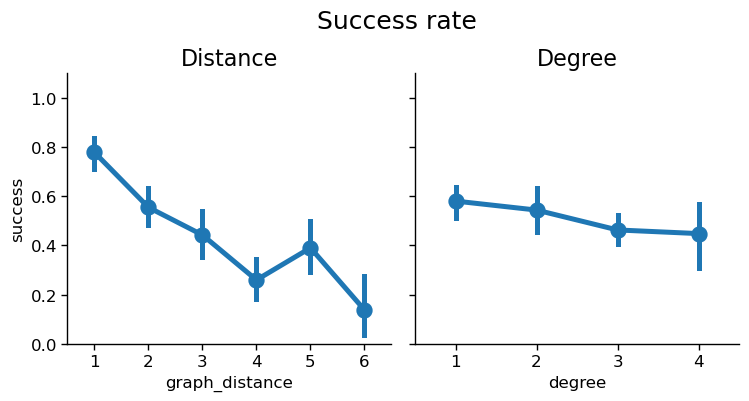

In [39]:
plt.close('all')
fig, axes = plt.subplots(1,2,figsize=(9,4),sharey=True)

ax=axes[0]
sns.pointplot(data=nav_trial,x='graph_distance',y='success',native_scale=True, ax=axes[0])
ax.set_ylim([0,1.1])
ax.set_xlim([0.5,6.5])
ax.set_title('Distance',fontsize=16)

ax=axes[1]
sns.pointplot(data=nav_trial,x='degree',y='success', native_scale=True, ax=axes[1])
ax.set_ylim([0,1.1])
ax.set_xlim([0.5,4.5])
ax.set_title('Degree',fontsize=16)
        
sns.despine()

fig.tight_layout(rect=[0.05, 0, 0.9, 0.95])
plt.suptitle('Success rate',fontsize=18, y=1)
# plt.savefig(f'{date} Success rate.png')

In [25]:
import statsmodels.formula.api as smf

In [51]:
model = smf.ols(formula='RT ~ success + EngagedTrialsInBlock + graph_distance', data=nav_trial)
results = model.fit()

In [53]:
results.pvalues[1]

C:\Users\Admin\AppData\Local\Temp\ipykernel_12040\2385771556.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results.pvalues[1]


np.float64(0.006429587197436057)

In [42]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     RT   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     3.441
Date:                Sun, 14 Jun 2026   Prob (F-statistic):             0.0165
Time:                        23:03:25   Log-Likelihood:                -5447.1
No. Observations:                 686   AIC:                         1.090e+04
Df Residuals:                     682   BIC:                         1.092e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept              620.3837     72.546      8.552      0.000     477.943     762.824
success[T.True]        -28.0486     55.654     -0.504      0.614    -137.323      81.226
EngagedTrialsInBlock    -3.2047      2.689     -1.192      0.234      -8.484       2.074
graph_distance          59.9114     20.994      2.854      0.004      18.690     101.133
==============================================================================
Omnibus:                     1299.116   Durbin-Watson:                   1.987
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          1617291.895
Skew:                          12.993   Prob(JB):                         0.00
Kurtosis:                     239.445   Cond. No.                         59.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### Reaction time as a function of distance and degree

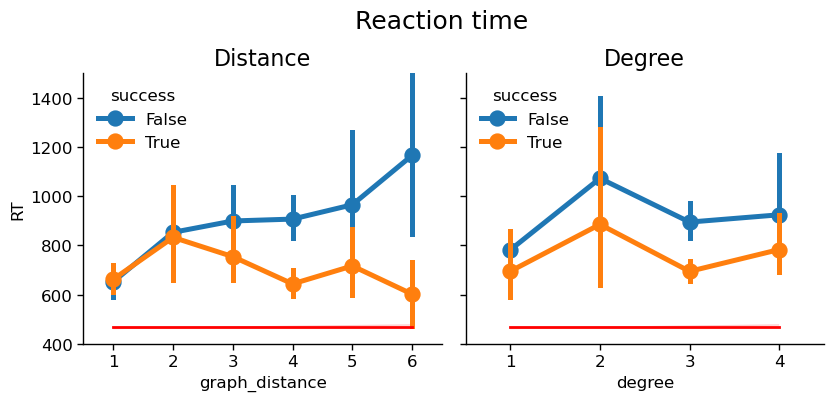

In [65]:
plt.close('all')
fig, axes = plt.subplots(1,2,figsize=(10,4),sharey=True)

ax=axes[0]
sns.pointplot(data=nav_trial,x='graph_distance',y='RT',hue='success',native_scale=True, ax=axes[0])
ax.plot([1,6],[flash_trial.RT.mean(),flash_trial.RT.mean()],color='r')
ax.fill([1,6],[flash_trial.RT.mean()-flash_trial.RT.sem(),flash_trial.RT.mean()+flash_trial.RT.sem()],color='r',alpha=0.2)
ax.set_xlim([0.5,6.5])
ax.set_title('Distance',fontsize=16)
ax.set_ylim(400,1500)

ax=axes[1]
sns.pointplot(data=nav_trial,x='degree',y='RT',hue='success', native_scale=True, ax=axes[1])
ax.plot([1,4],[flash_trial.RT.mean(),flash_trial.RT.mean()],color='r')
ax.fill([1,4],[flash_trial.RT.mean()-flash_trial.RT.sem(),flash_trial.RT.mean()+flash_trial.RT.sem()],color='r',alpha=0.2)
ax.set_xlim([0.5,4.5])
ax.set_title('Degree',fontsize=16)
        
sns.despine()

fig.tight_layout(rect=[0.05, 0, 0.9, 0.95])
plt.suptitle('Reaction time',fontsize=18, y=1)
plt.savefig(f'{date} reaction time.png')

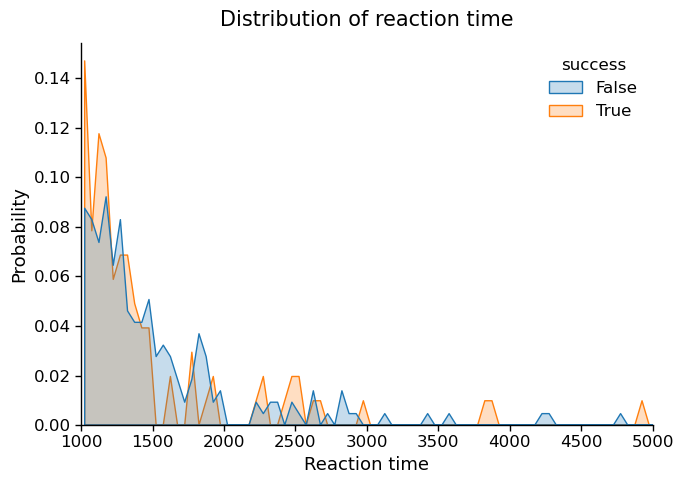

In [30]:
plt.close('all')

fig, ax = plt.subplots(figsize=(7,5))

sns.histplot(data=nav_trial,x='RT',hue='success',bins=np.arange(1000,6000,50),
             stat='probability',common_norm=False,#multiple='dodge',
             ax=ax, element="poly")

# sns.kdeplot(data=nav_trial,x='RT',hue='success',bw_adjust=0.1)

ax.set_xlabel('Reaction time', fontsize=13)
ax.set_ylabel('Probability', fontsize=13)
ax.set_title('Distribution of reaction time', fontsize=15, pad=12)

ax.set_xlim([1000,5000])

sns.despine()
plt.tight_layout()
plt.savefig('Distribution of reaction time')

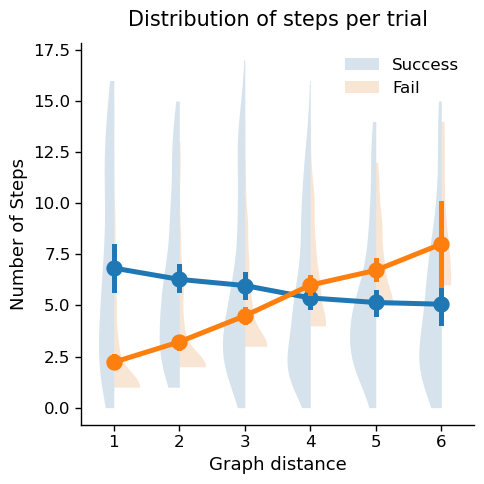

In [31]:
plt.close('all')

fig, ax = plt.subplots(figsize=(5,5))

sns.violinplot(data=nav_trial,y='minus_step',x='graph_distance',hue='success',split=True,alpha=0.2,inner=None,
    cut=0,
    linewidth=0,
    ax=ax
)

sns.pointplot(data=nav_trial,y='minus_step',x='graph_distance',hue='success',
    # dodge=True,
    # jitter=0.15,
    # alpha=0.25,
    # size=2.5,
    ax=ax
)

# Remove duplicate legends
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], {'Fail','Success'}, frameon=False, title='')

ax.set_ylabel('Number of Steps', fontsize=13)
ax.set_xlabel('Graph distance', fontsize=13)
ax.set_title('Distribution of steps per trial', fontsize=15, pad=12)

sns.despine()
plt.tight_layout()
plt.savefig('Distribution of steps per trial')

#### Detour index as a function of distance and degree

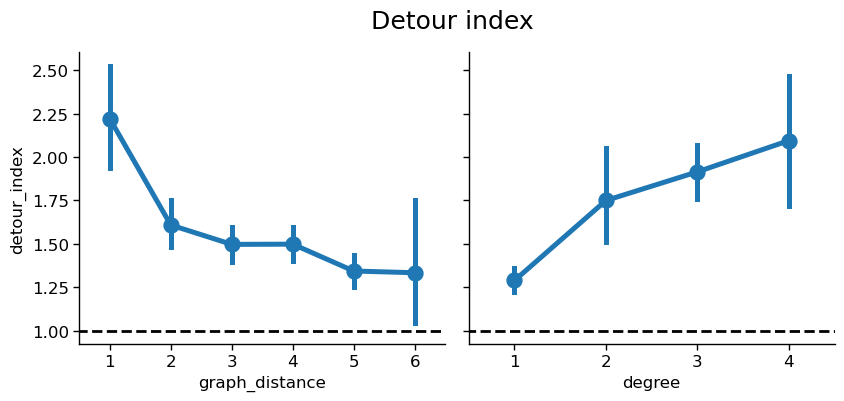

In [32]:
plt.close('all')
fig, axes = plt.subplots(1,2,figsize=(10,4),sharey=True)

ax=axes[0]
sns.pointplot(data=nav_trial[nav_trial.success],x='graph_distance',y='detour_index',native_scale=True, ax=axes[0])
ax.plot([-0.5,6.5],[1,1],'k--')
ax.set_xlim([0.5,6.5])

ax=axes[1]
sns.pointplot(data=nav_trial[nav_trial.success],x='degree',y='detour_index', native_scale=True, ax=axes[1])
ax.plot([-0.5,4.5],[1,1],'k--')
ax.set_xlim([0.5,4.5])
        
sns.despine()

fig.tight_layout(rect=[0.05, 0, 0.9, 0.95])
plt.suptitle('Detour index',fontsize=18, y=1)
plt.savefig(f'{date} detour index.png')

### Directions

### Room level performance

#### Room accuracy

In [33]:
# room accuracy
delta_dis = nav.graph_distance.diff().values[1:]
delta_dis = np.append(delta_dis,np.nan)
nav['room_accuracy'] = delta_dis==-1
nav.loc[nav.minus_step==0,'room_accuracy'] = np.nan

C:\Users\Admin\AppData\Local\Temp\ipykernel_12040\3000995760.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  nav.loc[nav.minus_step==0,'room_accuracy'] = np.nan


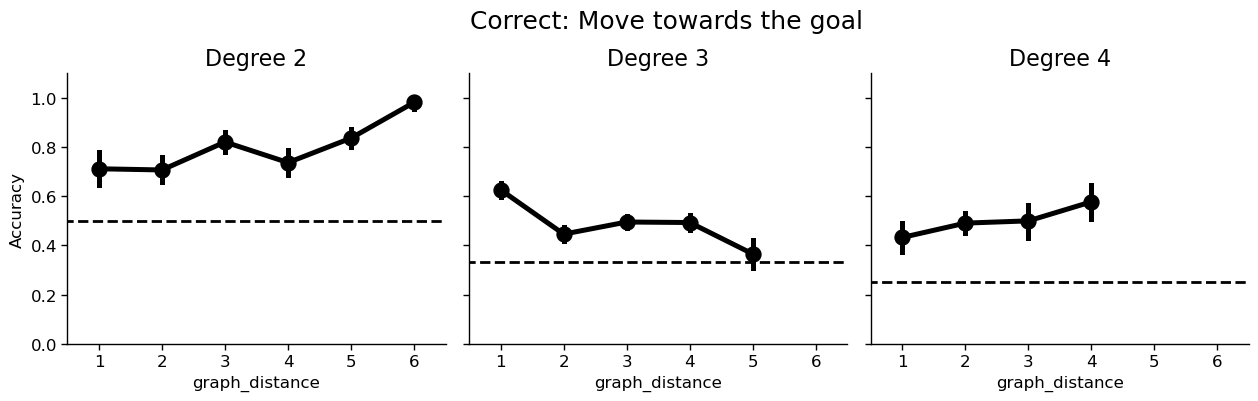

In [34]:
plt.close('all')
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for dd in range(3):
    ax = axes[dd]
    sns.pointplot(data=nav[(nav.graph_distance>0) & (nav.degree==dd+2)],x='graph_distance',y='room_accuracy',native_scale=True,ax=ax,color='k')
    ax.plot([-0.5,6.5],[1/(dd+2),1/(dd+2)],'k--')
    ax.set_ylim([0,1.1])
    ax.set_xlim([0.5,6.5])
    ax.set_title(f'Degree {dd+2}',fontsize=16)

    if dd==0:
        ax.set_ylabel('Accuracy')
        
sns.despine()
fig.tight_layout(rect=[0.05, 0, 0.9, 0.95])
plt.suptitle('Correct: Move towards the goal',fontsize=18, y=1)
plt.savefig('Room accuracy.png')

In [35]:
import statsmodels.api as sm

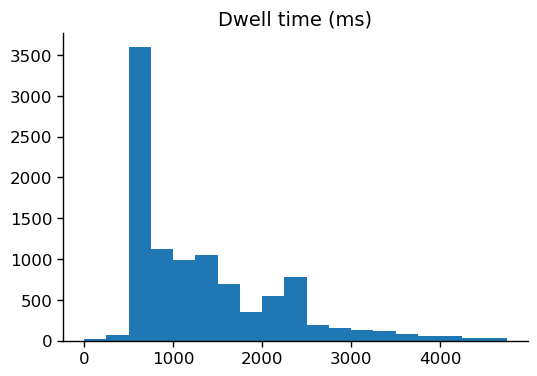

In [46]:
plt.close('all')
plt.figure(figsize=(6,4))
plt.hist(nav.duration.values,bins=np.arange(0,5000,250))
plt.title('Dwell time (ms)')
sns.despine()
# plt.savefig('Dwell time')

Text(0.5, 1.0, 'Dwell time & Distance')

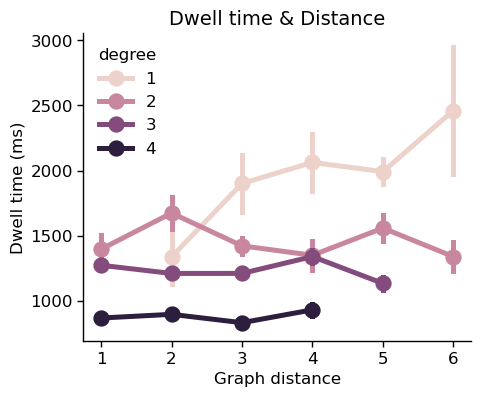

In [47]:
plt.close('all')
plt.figure(figsize=(5, 4))
df = nav[(nav.step>1)&(nav.minus_step>0)&(nav.graph_distance>0)]  
ax = sns.pointplot(data=df,x='graph_distance',y='duration',native_scale=True,hue='degree',errorbar=('se', 1))
# handles, labels = ax.get_legend_handles_labels()
# ax.legend(handles, {'Fail','Success'}, frameon=False, title='')
# sns.regplot(data=df,x='graph_distance',y='duration',scatter=False,color='lightblue')

# mod = sm.OLS(df.duration.values,sm.add_constant(df.graph_distance.values))
# res = mod.fit()

# plt.text(
#     0.05, 0.95,
#     f'y = {res.params[1]:.2f}x + {res.params[0]:.2f}\nR2={res.rsquared:.2e}\npval={res.pvalues[1]:.2e}',
#     transform=plt.gca().transAxes,
#     va='top'
# )

sns.despine()
plt.ylabel('Dwell time (ms)')
plt.xlabel('Graph distance')
plt.title('Dwell time & Distance')
# plt.savefig('Dwell time and distance and degree')

Text(0.5, 1.0, 'Dwell time & Degree')

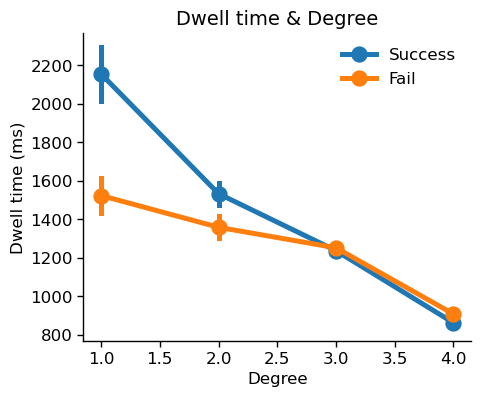

In [48]:
plt.close('all')
plt.figure(figsize=(5, 4))
df = nav[(nav.step>1)&(nav.minus_step>0)&(nav.graph_distance>0)]  # not the start, not the last room
ax = sns.pointplot(data=df,x='degree',y='duration',native_scale=True,hue='success',errorbar=('se', 1))

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, {'Fail','Success'}, frameon=False, title='')

# sns.regplot(data=df,x='graph_distance',y='duration',scatter=False,color='lightblue')

# mod = sm.OLS(df.duration.values,sm.add_constant(df.graph_distance.values))
# res = mod.fit()

# plt.text(
#     0.05, 0.95,
#     f'y = {res.params[1]:.2f}x + {res.params[0]:.2f}\nR2={res.rsquared:.2e}\npval={res.pvalues[1]:.2e}',
#     transform=plt.gca().transAxes,
#     va='top'
# )

sns.despine()
plt.ylabel('Dwell time (ms)')
plt.xlabel('Degree')
plt.title('Dwell time & Degree')
# plt.savefig('Dwell time and degree')

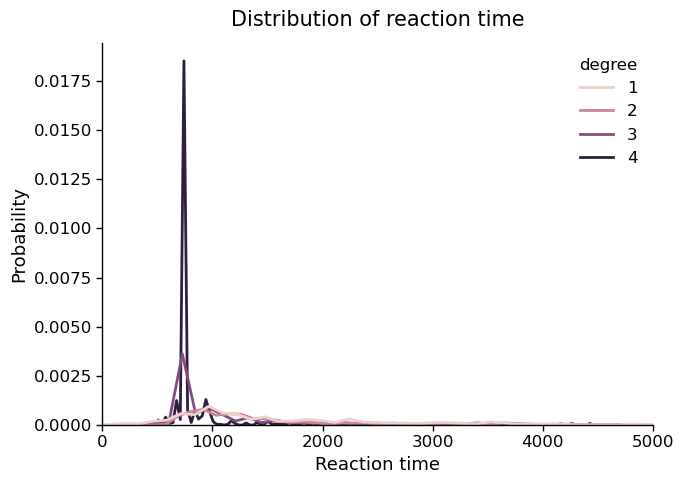

In [122]:
plt.close('all')
fig, ax = plt.subplots(figsize=(7,5))

df = nav[(nav.step>1)&(nav.minus_step>0)&(nav.graph_distance>0)]  #

sns.histplot(data=df,x='duration',hue='degree',bins=np.arange(0,3000,100),
             stat='probability',common_norm=False,#multiple='dodge',
             ax=ax, element="poly")

# sns.kdeplot(data=df,x='duration',hue='degree',bw_adjust=0.05,common_norm=False)

ax.set_xlabel('Reaction time', fontsize=13)
ax.set_ylabel('Probability', fontsize=13)
ax.set_title('Distribution of reaction time', fontsize=15, pad=12)

ax.set_xlim([0,5000])
# ax.set_yscale('log')

sns.despine()
plt.tight_layout()
# plt.savefig('Distribution of reaction time')

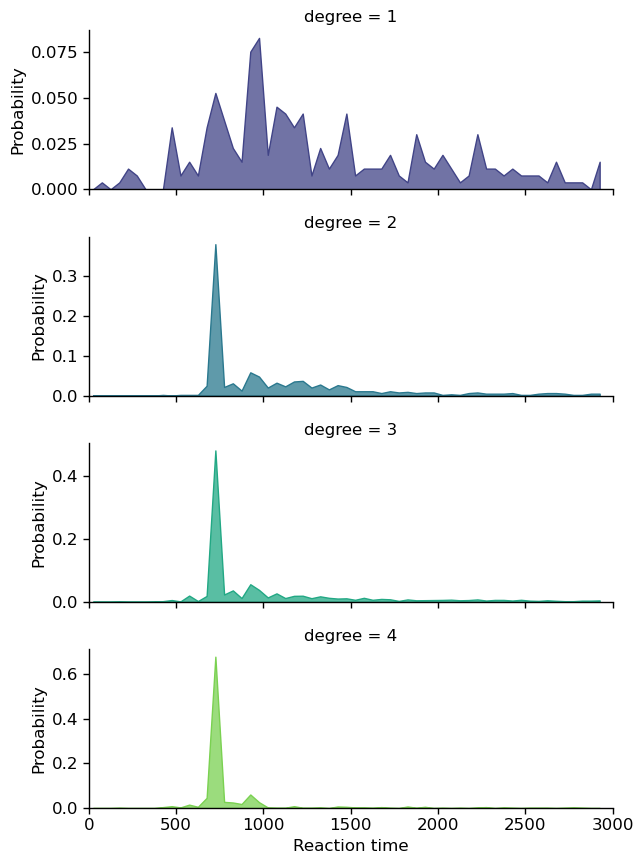

In [137]:
degrees = sorted(df.degree.unique())
palette = sns.color_palette("viridis", len(degrees))

g = sns.FacetGrid(df,row='degree',hue='degree',
    palette=palette,height=2.2,aspect=3,sharex=True,sharey=False)

g.map_dataframe(
    sns.histplot,
    x='duration',bins=np.arange(0,3000,50),
             stat='probability',common_norm=False,#multiple='dodge',
             element="poly"
)

g.set_axis_labels('Reaction time', 'Probability')
g.set(xlim=(0, 3000))

sns.despine()
plt.tight_layout()

### Deliberation

#### Pauses
pauses seem to develop over time within a block -> look at 06/03, pauses at room 9, target is 4 and 12

In [140]:
df0603 = nav[(nav.Session==260603) & (nav.minus_step>0)].copy()
df0603['room_cumcount'] = df0603.groupby('current').cumcount()

<Axes: xlabel='current', ylabel='duration'>

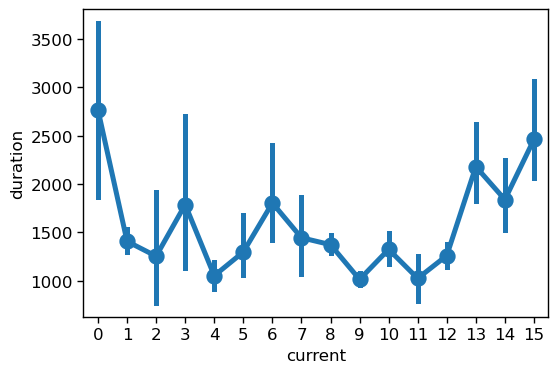

In [141]:
plt.close('all')
sns.pointplot(data=df0603,x='current',y='duration')

(500.0, 3000.0)

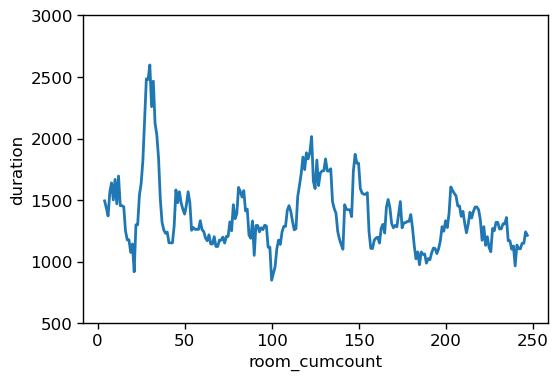

In [144]:
plt.close('all')
sns.lineplot(data=df0603[df0603.current==8].rolling(9,center=True).mean(),x='room_cumcount',y='duration')
# sns.lineplot(data=df0603[df0603.current==15].rolling(10,center=True).mean(),x='room_cumcount',y='duration')
plt.ylim(500,3000)

#### look at the success trials, which path led to success and if that is on the optimal trakectory

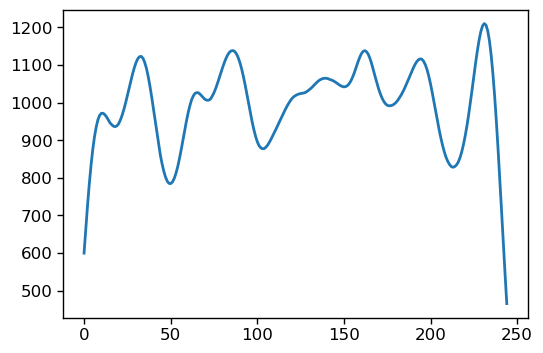

In [228]:
sigma = 2
radius = int(3 * sigma)  # kernel extends ±3σ

t = np.linspace(-radius, radius + 1,40)
kernel = np.exp(-0.5 * (t / sigma)**2)
kernel /= kernel.sum()

plt.close('all')
a = np.convolve(df0603[df0603.current==9].duration.values, kernel, mode='same')
plt.plot(a)

### Trajectory analysis

In [67]:
# when multiple optimal trajectory exist, does he tend to use the one with minimal changes of direction?

In [184]:
optimal_trials = nav_trial[(nav_trial.detour_index==1)&(nav_trial.graph_distance>1)&(nav_trial.success)].copy()

In [210]:
optimal_path_num = np.zeros(len(nav_trial))
is_min_action_path = np.zeros(len(nav_trial))
min_changes  = np.zeros(len(nav_trial))
actual_changes = np.zeros(len(nav_trial))

for idx in range(len(nav_trial)):
    
    start = int(nav_trial.iloc[idx].start)
    target = int(nav_trial.iloc[idx].target)
    paths = list(nx.all_shortest_paths(G, source=start, target=target))
    
    npath = len(paths)
    changes = np.zeros(npath)
    
    for ii in range(npath):
        actions = path2action(paths[ii])
        changes[ii] = sum(np.diff(actions)!=0) + 1
    
    min_action_path = paths[np.argmin(changes)]
    
    actualpath = nav_trial.iloc[idx].rooms
    actualactions = path2action(actualpath)
    actualchanges = sum(np.diff(actualactions)!=0) + 1
    
    optimal_path_num[idx] = npath
    is_min_action_path[idx] = min_action_path == actualpath
    min_changes[idx] = np.min(changes)
    actual_changes[idx] = actualchanges

nav_trial['optimal_path_num'] = optimal_path_num
nav_trial['is_min_action_path'] = is_min_action_path
nav_trial['min_actions'] = min_changes
nav_trial['actual_actions'] = actual_changes

In [211]:
res = smf.logit(
    'success ~ min_actions + graph_distance',
    data=nav_trial
).fit()

Optimization terminated successfully.
         Current function value: 0.613865
         Iterations 5


In [213]:
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                success   No. Observations:                 1891
Model:                          Logit   Df Residuals:                     1888
Method:                           MLE   Df Model:                            2
Date:                Mon, 15 Jun 2026   Pseudo R-squ.:                  0.1144
Time:                        12:25:23   Log-Likelihood:                -1160.8
converged:                       True   LL-Null:                       -1310.7
Covariance Type:            nonrobust   LLR p-value:                 7.777e-66
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          1.9742      0.134     14.741      0.000       1.712       2.237
min_actions       -0.7329      0.099     -7.389      0.000      -0.927      -0.539
graph_distance    -0.1244      0.067     -1.860      0.063      -0.255       0.007
==================================================================================
"""

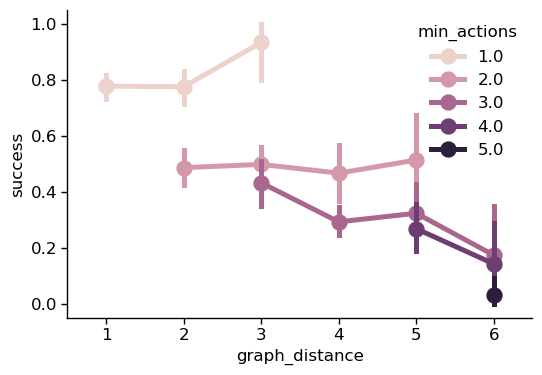

In [215]:
plt.close('all')
plt.figure(figsize=(6,4))
sns.pointplot(data = nav_trial, hue='min_actions', y='success',x='graph_distance')
sns.despine()
plt.savefig('Distance & Action on success')

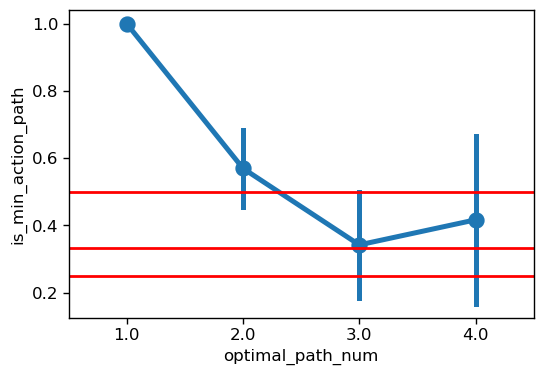

In [195]:
plt.close('all')
sns.pointplot(data = optimal_trials,x='optimal_path_num', y='is_min_action_path')
plt.axhline(0.5,color='r')
plt.axhline(1/3,color='r')
plt.axhline(1/4,color='r')

In [165]:
def path2action(path):
    
    actions = []
    for ii in range(len(path)-1):
        if path[ii]!=path[ii+1]:
            actions.append(edge2action(path[ii],path[ii+1]))

    return actions

In [167]:
def edge2action(n1,n2):

    if n2-n1 == -1:
        action = 0

    if n2-n1 == 1:
        action = 1

    if n2-n1 == 4:
        action = 2

    if n2-n1 == -4:
        action = 3

    # keep it consistent with RL gym
    # self._action_to_delta = {
    #     0: ( 0, -1),   # Left
    #     1: ( 0,  1),   # Right
    #     2: ( 1,  0),   # Up
    #     3: ( -1, 0),   # Down
    # }
    
    return action

<Axes: xlabel='graph_distance', ylabel='Count'>

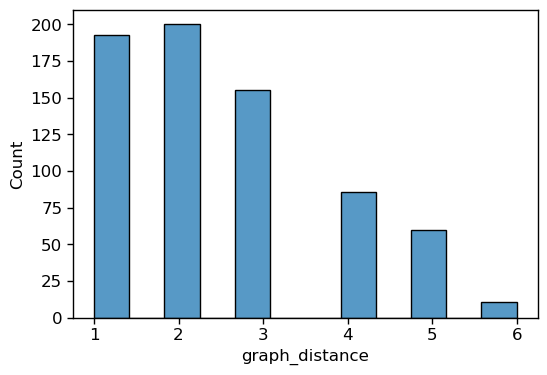

In [72]:
plt.close('all')
sns.histplot(data=optimal_trials, x='graph_distance')

In [232]:
nav['next'] = nav.groupby(['Session','Trial'])['current'].shift(-1)

# remove last state of each trial (no next state)
transitions = nav[(nav.BlockNumber==0)&(nav.TrialError==0)].dropna(subset=['next'])

transition_matrix = pd.crosstab(
    transitions['current'],
    transitions['next']
)

transition_prob = (
    transition_matrix
    .div(transition_matrix.sum(axis=1), axis=0)
)

nav['transition'] = list(zip(nav['current'], nav['next']))

In [140]:
from scipy.ndimage import gaussian_filter1d

In [164]:
# frequency of route (checking which direction enters the target room), is it the optimal route?

In [165]:
import networkx as nx
from collections import defaultdict, Counter
import itertools
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# ─────────────────────────────────────────────
# 1.  EXTRACT PATHS & TRANSITIONS
# ─────────────────────────────────────────────
def extract_paths_and_transitions(df):
    """
    Returns
    -------
    paths        : dict  {trial_id: [s0, s1, s2, ...]}
    transitions  : Counter  {(s_t, s_t1): count}
    """
    df = df.sort_values(["trial_id", "step"])
    paths = {}
    transitions = Counter()

    for trial_id, grp in df.groupby("trial_id"):
        states = grp["state"].tolist()
        paths[trial_id] = states
        for s_t, s_t1 in zip(states[:-1], states[1:]):
            transitions[(s_t, s_t1)] += 1

    return paths, transitions


# ─────────────────────────────────────────────
# 2.  BUILD DIRECTED GRAPH FROM TRANSITIONS
# ─────────────────────────────────────────────
def build_graph(transitions):
    G = nx.DiGraph()
    for (u, v), count in transitions.items():
        G.add_edge(u, v, weight=count)
    return G


# ─────────────────────────────────────────────
# 3.  PATH → EDGE SET
# ─────────────────────────────────────────────
def path_to_edges(path):
    """Convert a node sequence to a frozenset of directed edges."""
    return frozenset(zip(path[:-1], path[1:]))


# ─────────────────────────────────────────────
# 4.  SIMILARITY METRICS
# ─────────────────────────────────────────────

#### does he tend to switch trajectories after failed?

-> rather than repeating the same action as q learning suggested, does he tend to repeat the same action sequence / state sequence
-> does he tend to change actions more intentionally -> more than predicted by model-free which is mostly driven by devaluation and beta I guess?
-> to assess, does beta change throughout a trial?

In [250]:
sigma = 2
radius = int(3 * sigma)  # kernel extends ±3σ

t = np.linspace(-radius, radius + 1,5)
kernel = np.exp(-0.5 * (t / sigma)**2)
kernel /= kernel.sum()

#### edge that is closer to the goal has higher weight

In [185]:
def common_edges(a, b):
    """
    |A ∩ B| / |A ∪ B|
    1.0 = identical paths, 0.0 = no shared edges
    """

    edges_a = nav[nav.Trial==a].transition.values
    edges_b = nav[nav.Trial==b].transition.values
    
    set_a = set(edges_a)
    set_b = set(edges_b)
    
    intersection = set_a & set_b
    
    return intersection 

In [310]:
def compute_trial_probs(row, G):
    target = row['target']
    start = row['start']
    lastroom = row['lastroom']

    possible_nodes = list(nx.neighbors(G, target))

    # ---- actual policy (deterministic one-hot) ----
    actual_prob = (np.array(possible_nodes) == lastroom).astype(float)

    # ---- optimal policy (distribution over shortest paths) ----
    paths = list(nx.all_shortest_paths(G, source=start, target=target))
    lastnodes_optimal = np.array(paths)[:, -2]

    optimal_prob = np.array([
        np.mean(lastnodes_optimal == v) for v in possible_nodes
    ])

    return possible_nodes, actual_prob, optimal_prob

In [364]:
rows = []
kl_div = np.zeros(len(nav_success))
n_nodes = np.zeros(len(nav_success))

for idx, row in nav_success.iterrows():

    possible_nodes, actual_prob, optimal_prob = compute_trial_probs(row, G)
    kl_div[idx] = scipy.stats.entropy(actual_prob, optimal_prob)
    n_nodes[idx] = len(possible_nodes)

    for node, a, o in zip(possible_nodes, actual_prob, optimal_prob):
        rows.append({
            'Session': row['Session'],
            'target': row['target'],
            'start': row['start'],
            'trial': idx,
            'node': node,
            'actual_prob': a,
            'optimal_prob': o
        })

prob_df = pd.DataFrame(rows)
prob_df['bias'] = prob_df['actual_prob'] - prob_df['optimal_prob']

nav_success['kl_div'] = kl_div
nav_success['n_nodes'] = n_nodes

In [349]:
actual_prob = []
optimal_prob = []
for i
prob_df.groupby(['target','start','node']).optimal_prob.mean()

target  start  node
3       0      2       1.0
               7       0.0
        1      2       1.0
               7       0.0
        2      2       1.0
                      ... 
15      10     14      1.0
        11     14      1.0
        12     14      1.0
        13     14      1.0
        14     14      1.0
Name: optimal_prob, Length: 342, dtype: float64

In [ ]:
n=10

prob_df['actual_prob_smooth'] = (
    prob_df.groupby(['target', 'node'])['actual_prob']
           .transform(lambda x: x.rolling(n, center=True, min_periods=1).mean())
)

prob_df['optimal_prob_smooth'] = (
    prob_df.groupby(['target', 'node'])['optimal_prob']
           .transform(lambda x: x.rolling(n, center=True, min_periods=1).mean())
)

prob_df['bias_smooth'] = (
    prob_df.groupby(['target', 'node'])['bias']
           .transform(lambda x: x.rolling(n, center=True, min_periods=1).mean())
)

In [393]:
for target, df in prob_df.groupby('target'):

    if target==7:
        
        fig, axes = plt.subplots(1, 3, figsize=(12,5), sharex=True)
        titles = ['data','optimal','bias']
        
        for ii, (ax, col) in enumerate(zip(
            axes,
            ['actual_prob_smooth', 'optimal_prob_smooth', 'bias_smooth']
        )):
            sns.lineplot(
                data=df,
                x='trial',
                y=col,
                hue='node',
                ax=ax,
                legend=(ax is axes[2]),
                palette='Set1'
            )
            ax.set_ylabel('')
            ax.set_title(titles[ii])
    
            if ii<2:
                ax.set_ylim(-0.1,0.9)
        
        sns.despine()
        plt.tight_layout(rect=[0.05,0.1,0.9,0.85])
        plt.suptitle(f'Target {target}',y=0.9,fontsize=18)
        fig.savefig(f'Target_{target}_path_bias.png')
        plt.close(fig)

In [ ]:
# ─────────────────────────────────────────────
# 5.  ENUMERATE SIMPLE ALTERNATIVE PATHS
# ─────────────────────────────────────────────
def get_alternative_paths(G, origin, destination, cutoff=10, max_paths=50):
    """
    Return up to `max_paths` simple paths from origin to destination.
    `cutoff` limits path length to keep enumeration tractable.
    """
    try:
        gen = nx.all_simple_paths(G, origin, destination, cutoff=cutoff)
        return list(itertools.islice(gen, max_paths))
    except (nx.NetworkXNoPath, nx.NodeNotFound):
        return []


# ─────────────────────────────────────────────
# 6.  PER-OD SIMILARITY ANALYSIS
# ─────────────────────────────────────────────
def analyze_od_pair(od, trials_for_od, G, cutoff=10, max_paths=50):
    """
    For one OD pair:
      - collect all observed paths
      - enumerate alternatives on G
      - compute Jaccard & overlap between every observed path and every alternative
      - summarise which alternative is most consistently chosen

    Returns a dict with summary statistics and per-trial details.
    """
    origin, destination = od

    # --- alternatives ---
    alternatives = get_alternative_paths(G, origin, destination, cutoff, max_paths)
    if not alternatives:
        return None

    alt_edges = [path_to_edges(p) for p in alternatives]

    # --- per-trial similarity ---
    records = []
    for trial_id, obs_path in trials_for_od:
        obs_edges = path_to_edges(obs_path)
        for alt_idx, (alt_path, ae) in enumerate(zip(alternatives, alt_edges)):
            j = jaccard_similarity(obs_edges, ae)
            eor = edge_overlap_ratio(obs_edges, ae)
            records.append({
                "trial_id":         trial_id,
                "od":               od,
                "obs_path":         tuple(obs_path),
                "alt_idx":          alt_idx,
                "alt_path":         tuple(alt_path),
                "jaccard":          j,
                "edge_overlap":     eor,
                "exact_match":      obs_edges == ae,
            })

    detail_df = pd.DataFrame(records)

    # --- best-matching alternative per trial ---
    best_per_trial = (
        detail_df.sort_values("jaccard", ascending=False)
        .groupby("trial_id")
        .first()
        .reset_index()
    )

    # --- frequency: how often is each alternative the best match? ---
    alt_freq = best_per_trial["alt_path"].value_counts()

    # --- mean Jaccard of each alternative across all trials ---
    mean_jaccard = (
        detail_df.groupby("alt_path")["jaccard"]
        .mean()
        .sort_values(ascending=False)
    )

    # --- exact-match frequency ---
    exact_freq = detail_df[detail_df["exact_match"]].groupby("alt_path").size()

    return {
        "od":               od,
        "n_trials":         len(trials_for_od),
        "n_alternatives":   len(alternatives),
        "alternatives":     alternatives,
        "detail_df":        detail_df,
        "best_per_trial":   best_per_trial,
        "alt_frequency":    alt_freq,        # how often chosen as best match
        "mean_jaccard":     mean_jaccard,    # avg similarity to each alternative
        "exact_freq":       exact_freq,      # exact-match counts
    }


# ─────────────────────────────────────────────
# 7.  MAIN PIPELINE
# ─────────────────────────────────────────────
def run_analysis(df, cutoff=10, max_paths=50):
    """
    Full pipeline.

    Parameters
    ----------
    df        : long-format DataFrame with columns [trial_id, step, state]
    cutoff    : max path length when enumerating alternatives
    max_paths : cap on number of alternatives per OD pair

    Returns
    -------
    paths            : dict  {trial_id: path}
    transitions      : Counter of edge frequencies
    G                : DiGraph
    transition_df    : tidy DataFrame of all (from, to, count) transitions
    od_results       : dict  {(origin, dest): analysis_dict}
    summary_df       : one row per OD pair with headline stats
    """
    paths, transitions = extract_paths_and_transitions(df)
    G = build_graph(transitions)

    # tidy transition table
    transition_df = pd.DataFrame(
        [(u, v, c) for (u, v), c in transitions.items()],
        columns=["from_state", "to_state", "count"]
    ).sort_values("count", ascending=False).reset_index(drop=True)

    # group trials by OD pair
    od_to_trials = defaultdict(list)
    for trial_id, path in paths.items():
        od = (path[0], path[-1])
        od_to_trials[od].append((trial_id, path))

    # run per-OD analysis
    od_results = {}
    for od, trials in od_to_trials.items():
        result = analyze_od_pair(od, trials, G, cutoff, max_paths)
        if result:
            od_results[od] = result

    # headline summary
    summary_rows = []
    for od, r in od_results.items():
        top_alt = r["alt_frequency"].index[0] if len(r["alt_frequency"]) else None
        top_freq = r["alt_frequency"].iloc[0] if len(r["alt_frequency"]) else 0
        top_jaccard = r["mean_jaccard"].iloc[0] if len(r["mean_jaccard"]) else np.nan
        summary_rows.append({
            "origin":               od[0],
            "destination":          od[1],
            "n_trials":             r["n_trials"],
            "n_alternatives":       r["n_alternatives"],
            "most_chosen_alt":      top_alt,
            "times_best_match":     top_freq,
            "pct_best_match":       round(top_freq / r["n_trials"] * 100, 1),
            "top_mean_jaccard":     round(top_jaccard, 3),
        })
    summary_df = pd.DataFrame(summary_rows)

    return paths, transitions, G, transition_df, od_results, summary_df


# ─────────────────────────────────────────────
# 8.  RUN & PRINT RESULTS
# ─────────────────────────────────────────────
if __name__ == "__main__":
    df = make_synthetic_data(n_trials=100)

    paths, transitions, G, transition_df, od_results, summary_df = run_analysis(df)

    print("=" * 60)
    print("TRANSITION FREQUENCIES  (top 10)")
    print("=" * 60)
    print(transition_df.head(10).to_string(index=False))

    print("\n" + "=" * 60)
    print("OD-PAIR SUMMARY")
    print("=" * 60)
    print(summary_df.to_string(index=False))

    for od, r in od_results.items():
        print(f"\n{'─'*60}")
        print(f"OD pair {od[0]} → {od[1]}  ({r['n_trials']} trials, "
              f"{r['n_alternatives']} alternatives)")
        print("  Mean Jaccard per alternative:")
        for path, score in r["mean_jaccard"].items():
            exact = r["exact_freq"].get(path, 0)
            print(f"    {list(path)}  jaccard={score:.3f}  exact_matches={exact}")

#### actual transition probability

#### transition probability if taken optimal path

#### does the animal tend to take previously successful but suboptimal edges/paths?

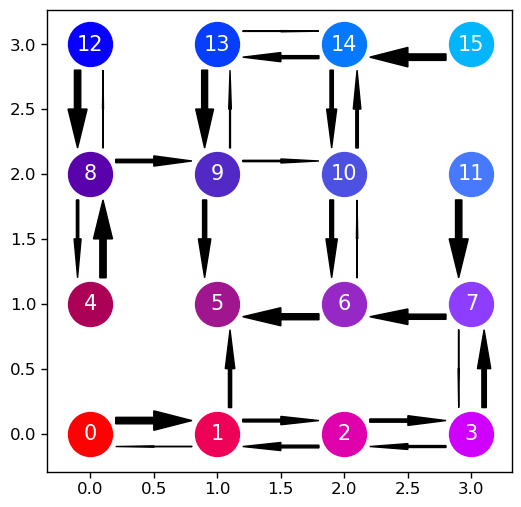

In [107]:
head_width = 0.1
arrow_length = 0.7
offset = 0.1
head_length = 0.3

plt.close('all')
plt.figure(figsize=(6,6))

# draw nodes
for node in range(16):
    x, y = xy(node, 4, 4)
    plt.scatter(x, y, s=1000, color=cmap_2d[x, y])
    plt.text(x, y, str(node),
             fontsize=15, ha='center', va='center', color='w')

# draw transitions
for prenode in transition_matrix.index:
    for node in transition_matrix.columns:

        freq = transition_prob.loc[prenode, node]

        # skip absent transitions
        if freq == 0:
            continue

        x, y = xy(node, 4, 4)
        x_pre, y_pre = xy(prenode, 4, 4)

        # optionally only show neighboring transitions
        if abs(x - x_pre) + abs(y - y_pre) != 1:
            continue

        width = freq * 0.05   # adjust scaling

        if x == x_pre:
            if y > y_pre:
                plt.arrow(x_pre + offset, y_pre + 0.2,
                          x - x_pre, y - y_pre - arrow_length,
                          width=width, color='k',
                          head_width=width*3,head_length=head_length)
            else:
                plt.arrow(x_pre - offset, y_pre - 0.2,
                          x - x_pre, y - y_pre + arrow_length,
                          width=width, color='k',
                          head_width=width*3,head_length=head_length)

        elif y == y_pre:
            if x > x_pre:
                plt.arrow(x_pre + 0.2, y_pre + offset,
                          x - x_pre - arrow_length, y - y_pre,
                          width=width, color='k',
                         head_width=width*3,head_length=head_length)
            else:
                plt.arrow(x_pre - 0.2, y_pre - offset,
                          x - x_pre + arrow_length, y - y_pre,
                          width=width, color='k',
                         head_width=width*3,head_length=head_length)

In [66]:
from matplotlib.colors import LinearSegmentedColormap
def interpolate_colors(color1, color2, num_colors):
    """
    Interpolates a list of colors between two given colors.

    Parameters:
    color1 (str or tuple): The starting color, can be a name or an RGB tuple.
    color2 (str or tuple): The ending color, can be a name or an RGB tuple.
    num_colors (int): The number of colors to generate between color1 and color2.

    Returns:
    list: A list of interpolated colors in RGBA format.
    """
    cmap = LinearSegmentedColormap.from_list('custom_cmap', [color1, color2], N=num_colors)
    colors = [cmap(i) for i in range(num_colors)]
    return colors

    
def xy(node, nrows, ncols):
    """
    Transforms the node identity into X, y coordinates
    :param node: (int) node ID
    :param nrows: (int) number of rows
    :param ncols: (int) number of columns
    :return: (X, Y): (tuple) pair of XY coords
    """
    X = int(node % nrows)
    Y = int(np.floor(node / ncols))
    return X, Y

c1 = "#fc0303" # red
c2 = "#d000ff" # purple
c3 = "#0800ff" # blue
c4 = "#03b6fc" # cyan

caxis_1 = interpolate_colors(c1, c2, 4)
caxis_2 = interpolate_colors(c3, c4, 4)
cmap_2d = np.array([interpolate_colors(caxis_1[i], caxis_2[i], 4) for i in range(4)])

In [ ]:
plt.close('all')
plt.figure(figsize=(6, 6))

for node in range(16):

    x, y = xy(node, 4, 4)
    plt.scatter(x, y, s=1000, color = cmap_2d[x, y])
    plt.text(x, y, str(node), fontsize=15, ha='center', va='center', color='w')
    

for (prenode, node),freq  in transition_prob[['edge','trans_freq%i'%target]].values:
    
    x, y = xy(node, 4, 4)
    x_pre, y_pre = xy(prenode, 4, 4)    
    freq=freq*1.2

    if x==x_pre:
        if y>y_pre:
            plt.arrow(x_pre, y_pre+0.2, x-x_pre, y-y_pre-0.4, width=freq, color='k',head_width=0)
        else:
            plt.arrow(x_pre, y_pre-0.2, x-x_pre, y-y_pre+0.4, width=freq, color='k',head_width=0)

    if y==y_pre:
        if x>x_pre:
            plt.arrow(x_pre+0.2, y_pre, x-x_pre-0.4, y-y_pre, width=freq, color='k',head_width=0)
        else:
            plt.arrow(x_pre-0.2, y_pre, x-x_pre+0.4, y-y_pre, width=freq, color='k',head_width=0)   

    
plt.xlim([-0.5, 3.5])
plt.ylim([-0.5, 3.5])
plt.xticks([0, 1, 2, 3], labels = ["", "", "", ""])
plt.yticks([0, 1, 2, 3], labels = ["", "", "", ""])

ax = plt.gca()
ax.invert_yaxis()  # Invert the y-axis
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
sns.despine(left=True, bottom=True)
plt.title('Target %i'%target,fontsize=20)
plt.savefig('Transition frequency, target %i'%target)

### Learning

#### Trial performance

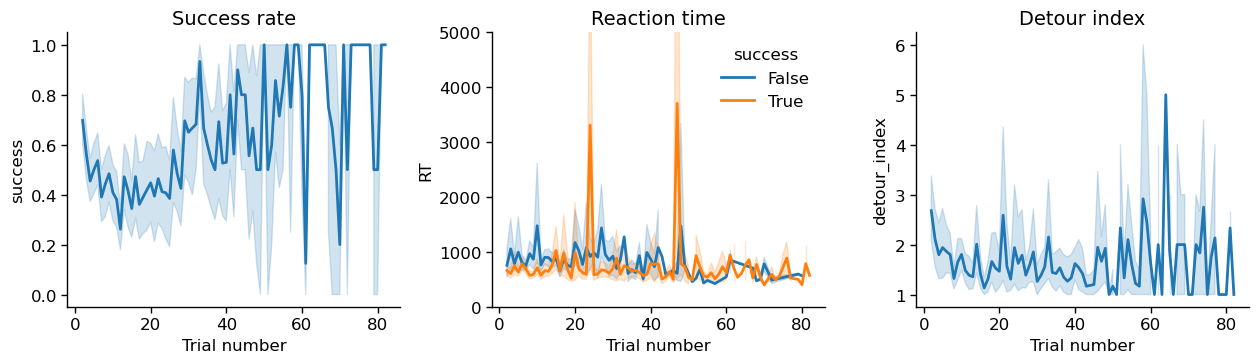

In [49]:
plt.close('all')
fig, axes = plt.subplots(1,3,figsize=(15,4))

sns.lineplot(data=nav_trial,x='correctTrialsInBlock',y='success', ax=axes[0])
axes[0].set_title('Success rate')
axes[0].set_xlabel('Trial number')

sns.lineplot(data=nav_trial,x='correctTrialsInBlock',y='RT', hue='success',ax=axes[1])
axes[1].set_title('Reaction time')
axes[1].set_ylim([0,5000])
axes[1].set_xlabel('Trial number')

sns.lineplot(data=nav_trial.query('success'),x='correctTrialsInBlock',y='detour_index', ax=axes[2])        
axes[2].set_title('Detour index')
axes[2].set_xlabel('Trial number')

sns.despine()

fig.tight_layout(rect=[0.05, 0, 0.9, 0.95])
# plt.suptitle('Learning in a block',fontsize=18, y=1)
# plt.savefig('Learning.png')

#### Room performance

In [153]:
nav[(nav.graph_distance>0) & (nav.degree==dd+2)].columns

Index(['Session', 'BlockNumber', 'InitiatedTrialsInBlock',
       'EngagedTrialsInBlock', 'correctTrialsInBlock', 'Trial', 'target_room',
       'start_room', 'TrialError', 'RT', 'step', 'minus_step', 'current_room',
       'graph_distance', 'degree', 'enter', 'exit', 'duration', 'target',
       'start', 'current', 'success', 'room_accuracy'],
      dtype='object')

ValueError: Could not interpret value `room_accuracy` for `y`. An entry with this name does not appear in `data`.

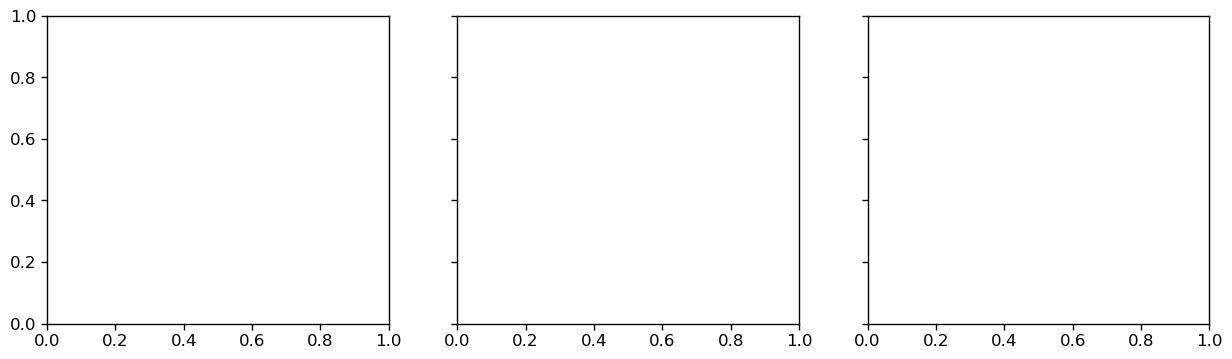

In [50]:
plt.close('all')
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for dd in range(3):
    ax = axes[dd]
    # sns.lineplot(data=nav[(nav.graph_distance>0) & (nav.degree==dd+2)],x='EngagedTrialsInBlock',y='room_accuracy',ax=ax)
    sns.lineplot(data=nav[(nav.graph_distance>0) & (nav.degree==dd+2)],x='EngagedTrialsInBlock',y='room_accuracy',ax=ax)
    ax.plot([-0.5,100],[1/(dd+2),1/(dd+2)],'k--')
    ax.set_ylim([0,1.1])
    # ax.set_xlim([0.5,6.5])
    ax.set_title(f'Degree {dd+2}',fontsize=16)

    if dd==0:
        ax.set_ylabel('Accuracy')
        
sns.despine()
fig.tight_layout(rect=[0.05, 0, 0.9, 0.95])
plt.suptitle('Correct: Move towards the goal',fontsize=18, y=1)
# plt.savefig('Room accuracy learning.png')

#### Same gradient vs different gradient

# Simulation

#### Create gym environment

In [157]:
class NewWorldEnv(gym.Env):
    
    def __init__(self):
        self.size = 4
        self.n_states = self.size ** 2   # 16
        self.n_actions = 4                # 0=Up 1=Right 2=Down 3=Left
        self.action_space = spaces.Discrete(self.n_actions)
        
        self._action_to_delta = {
            0: ( 0, -1),   # Left
            1: ( 0,  1),   # Right
            2: ( 1,  0),   # Up
            3: ( -1, 0),   # Down
        }

        # Build once at construction time
        self.T = self._build_transition_matrix()

    
    def _build_transition_matrix(self):
        """
        T[s, a, s'] = probability of reaching s' from s via action a.

        Rules:
          - Terminal states (goal): agent stays put (absorbing).
          - Wall collisions: agent stays in current cell.
          - Otherwise: deterministic move → probability 1.0.
        """
        
        T = np.zeros((self.n_states, self.n_actions, self.n_states))

        for s in range(self.n_states):

            for a, (dr, dc) in self._action_to_delta.items():
                row, col = divmod(s, self.size)
                new_row  = max(0, min(self.size - 1, row + dr))
                new_col  = max(0, min(self.size - 1, col + dc))
                s_next   = new_row * self.size + new_col
                T[s, a, s_next] = 1.0   # deterministic

                if (row + dr < 0) | (col + dc < 0) | (row + dr > (self.size-1)) | (col + dc > (self.size-1)): 
                    T[s, a, s_next] = 0   # deterministic

        # remove the transition when there is no connection between two states
        T[0,2,4] = 0
        T[4,3,0] = 0
        T[2,2,6] = 0
        T[6,3,2] = 0
        T[4,1,5] = 0
        T[5,0,4] = 0
        T[10,1,11] = 0
        T[11,0,10] = 0
        T[11,2,15] = 0
        T[15,3,11] = 0
        T[12,1,13] = 0
        T[13,0,12] = 0
        
        return T

    
    def _build_reward_vector(self):
        """R[s] — reward received upon *entering* state s."""
        R = np.full(self.n_states, -0.1)
        R[self.goal] = 10.0
        return R


    def reset(self, goal, start, seed=None, options=None):
        super().reset(seed=seed)
        self.goal = goal
        self.agent_pos = start   
        self.R = self._build_reward_vector()
        self.steps = 0
        obs = self.agent_pos
        info = {}
        return obs, info

    
    def step(self, action, cutoff):

        self.agent_pos = np.where(self.T[self.agent_pos,action,:])[0][0]
        self.steps += 1

        # Rewards & termination
        reward = self.R[self.agent_pos]
        if self.agent_pos == self.goal:
            terminated = True
        else:
            terminated = False   

        truncated = self.steps >= cutoff          # episode cut-off, time-limit is 30s, 1 step is 
        obs  = self.agent_pos
        info = {"steps": self.steps}
        return obs, reward, terminated, truncated, info

    
    def close(self):
        pass

In [402]:
def simulate_a_session(data, model, nrep = 100):

    # this is the common structure across null models - mostly create a workable dataframe
        
    df = data.copy()
    ntrials = len(df)
    sim_trial = pd.DataFrame()
    sim_room = pd.DataFrame()
    env = NewWorldEnv()

    for n in range(nrep):
        
        if model is model3:
            Qa = np.zeros(4)
            
        if model is model4:
            Qsa = np.zeros((16,4))
            Qsa[env.T.sum(axis=2)==0] = np.nan

        for trial in range(ntrials):
                
            target = df.iloc[trial].target
            start = df.iloc[trial].start
            trial_df = df.iloc[[trial]][['Session','BlockNumber','EngagedTrialsInBlock', 'target', 'start','minus_step']].copy()
            cutoff = trial_df['minus_step'].values[0]
            
            obs, info = env.reset(target,start)
            action = []
            
            temp = trial_df.copy()
            temp[['nrep','step', 'current', 'graph_distance', 'degree']] = [n,0,obs, 
                                                nx.shortest_path_length(G, source=obs, target=target),G.degree[obs]]
            sim_room = pd.concat([sim_room,temp])
            
            while True:
                if model is model1:
                    obs, reward, terminated, truncated, info = model1(env, obs, info, cutoff=cutoff)
                if model is model2:
                    obs, reward, terminated, truncated, info, action = model(env,obs,info, action,cutoff=cutoff)
                if model is model3:
                    Qa, obs, reward, terminated, truncated, info = model(Qa,env,obs,cutoff=cutoff)
                if model is model4:
                    Qsa, obs, reward, terminated, truncated, info = model(Qsa,env,obs,cutoff=cutoff)

                temp = trial_df.copy()
                temp[['nrep','step', 'current', 'graph_distance', 'degree']] = [n,info['steps'],obs, 
                                                    nx.shortest_path_length(G, source=obs, target=target),G.degree[obs]]
                sim_room = pd.concat([sim_room,temp])
                
                if terminated:
                    break
                    
                if truncated:
                    break
            

            temp = df.iloc[[trial]][['Session','BlockNumber','EngagedTrialsInBlock', 'target', 'start', 'graph_distance', 'degree']].copy()
            temp[['nrep','minus_step', 'success', 'detour_index']] = [n,info['steps'],terminated, info['steps']/temp.graph_distance.values[0]]
            sim_trial = pd.concat([sim_trial,temp])

    return sim_trial, sim_room

#### Model 1: Random policy

In [400]:
def model1(nrep = 100, cutoff=30):
    
    steps = np.zeros((16,16,nrep))
    success = np.zeros((16,16,nrep))
    
    for target in range(16):
    
        env = NewWorldEnv()
        
        for start in range(16):
            
            if target!=start:
                
                for n in range(nrep):
                
                    obs, info = env.reset(target,start)
                    total_reward = 0
                    
                    while True:
                        
                        valid_actions, _ = np.where(np.squeeze(env.T[obs,:,:]))
                        # choose a valid action randomly
                        action  = np.random.choice(valid_actions)     
                        obs, reward, terminated, truncated, info = env.step(action, cutoff)
                        total_reward += reward
                    
                        if terminated:
                            success[target,start,n] = 1
                            # print(f"Done! Total reward: {total_reward:.1f}")
                            break
                            
                        if truncated:
                            # print("Failed!")
                            break
                
                    steps[target,start,n] = info['steps']
            
    # print(f"steps taken: {info['steps']}")
    
    dist_matrix = shortest_path(env.T.sum(axis=1)>0, directed=False, unweighted=True)
    all_dis = np.tile(dist_matrix[:,:,None],(1,1,nrep))
    
    sim = pd.DataFrame({"target": np.ravel(np.tile(np.arange(16)[:,None,None],(1,16,nrep))), 
                       "start": np.ravel(np.tile(np.arange(16)[None,:,None],(16,1,nrep))),
                       "graph_distance": np.ravel(all_dis), 
                       "steps": np.ravel(steps),
                       "success": np.ravel(success)})
    sim = sim[sim.graph_distance>0]
    sim['detour_index'] = sim.steps/sim.graph_distance
    
    return sim

model1_df = model1()

In [401]:
def model1(env, obs, info, cutoff=30):
                        
    valid_actions, _ = np.where(np.squeeze(env.T[obs,:,:]))
    action  = np.random.choice(valid_actions)     
    obs, reward, terminated, truncated, info = env.step(action, cutoff)
    
    return obs, reward, terminated, truncated, info


#### Model 2: Choose one direction, hit wall, then change direction

In [183]:
def model2(env, obs, info, action, cutoff=30):
                
    # see what are the available actions in the current room
    valid_actions, _ = np.where(np.squeeze(env.T[obs,:,:]))
    
    if len(info) == 0:
        # choose an action to go at the start of a trial
        action  = np.random.choice(valid_actions) 
    else:
        # if previous action is valid, continue; if not, choose one randomly from valid actions
        if ~np.isin(action,valid_actions):
            action  = np.random.choice(valid_actions)     

    obs, reward, terminated, truncated, info = env.step(action, cutoff)

    return obs, reward, terminated, truncated, info, action

#### Model 3: Action learning, regardless of state
when there is learning component, transition between targets matter, some target transitons will be eaiser, some will be harder

In [184]:
def model3(Qa, env, obs, cutoff = 30, alpha=0.2):

    # choose action with softmax policy based on the accumulated action value
    valid_actions, _ = np.where(np.squeeze(env.T[obs,:,:]))
    policy = softmax(Qa[valid_actions])
    action = np.random.choice(valid_actions, p=policy)

    obs, reward, terminated, truncated, info = env.step(action, cutoff)
    Qa[action] = Qa[action] + alpha*(reward-Qa[action])

    return Qa, obs, reward, terminated, truncated, info

#### Model 4: Q learning

In [185]:
def model4(Qsa, env, obs, cutoff = 30, alpha = 0.1, gamma = 0.9):
    
    # choose action with softmax policy based on the accumulated action value
    s = obs
    valid_actions, _ = np.where(np.squeeze(env.T[obs,:,:]))
    policy = softmax(Qsa[s,valid_actions])
    action = np.random.choice(valid_actions, p=policy)
    obs, reward, terminated, truncated, info = env.step(action, cutoff)
    
    # update q value
    if terminated:
        Qsa[s,action] = Qsa[s,action] + alpha * (reward - Qsa[s,action])
    else:
        s_prime = list(G.neighbors(s))  # q learning is off-policy - find all possible successors
        Qsa[s,action] = Qsa[s,action] + alpha * (reward + gamma * np.nanmax(Qsa[s_prime]) - Qsa[s,action])

    return Qsa, obs, reward, terminated, truncated, info

#### Model 5: Successor representation

In [404]:
model1_trial, model1_room = simulate_a_session(nav_trial,model1,nrep=20)

KeyboardInterrupt: 

In [405]:
model1_trial30, model1_room30 = simulate_a_session(nav_trial,model1,nrep=20)

In [ ]:
model2_trial, model2_room = simulate_a_session(nav_trial,model2,nrep=20)
model3_trial, model3_room = simulate_a_session(nav_trial,model3,nrep=20)
model4_trial, model4_room = simulate_a_session(nav_trial,model4,nrep=20)

In [186]:
model2_trial30, model2_room30 = simulate_a_session(nav_trial,model2,nrep=20)
model3_trial30, model3_room30 = simulate_a_session(nav_trial,model3,nrep=20)
model4_trial30, model4_room30 = simulate_a_session(nav_trial,model4,nrep=20)

# Data & Model comparison

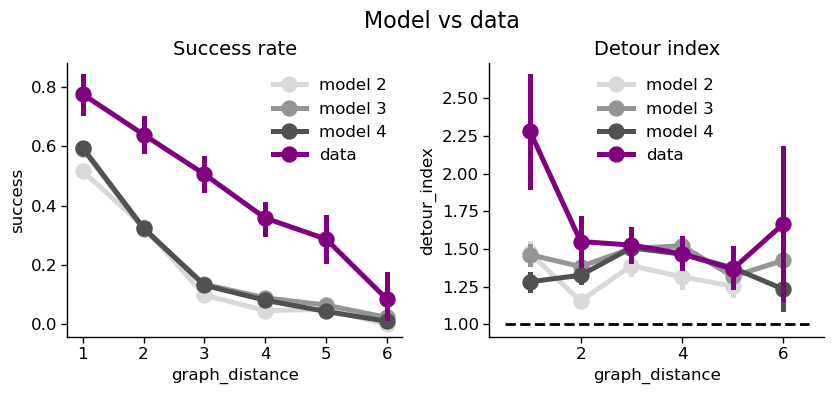

In [168]:
plt.close('all')
colors = sns.color_palette('Greys',3)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.pointplot(data = model2_trial, x = 'graph_distance', y = 'success', ax = ax[0], native_scale=True, color=colors[0], label='model 2')
sns.pointplot(data = model3_trial, x = 'graph_distance', y = 'success', ax = ax[0], native_scale=True, color=colors[1], label='model 3')
sns.pointplot(data = model4_trial, x = 'graph_distance', y = 'success', ax = ax[0], native_scale=True, color=colors[2], label='model 4')
sns.pointplot(data = nav_trial, x = 'graph_distance', y = 'success', ax = ax[0], native_scale=True, color='purple', label='data')
ax[0].set_title('Success rate', fontsize=14)

sns.pointplot(data = model2_trial[model2_trial.success==1], x = 'graph_distance', y = 'detour_index', ax = ax[1], native_scale=True, color=colors[0], label='model 2')
sns.pointplot(data = model3_trial[model3_trial.success==1], x = 'graph_distance', y = 'detour_index', ax = ax[1], native_scale=True, color=colors[1], label='model 3')
sns.pointplot(data = model4_trial[model4_trial.success==1], x = 'graph_distance', y = 'detour_index', ax = ax[1], native_scale=True, color=colors[2], label='model 4')
sns.pointplot(data = nav_trial[nav_trial.success==1], x = 'graph_distance', y = 'detour_index', ax = ax[1], native_scale=True, color='purple', label='data')
ax[1].set_title('Detour index', fontsize=14)
ax[1].plot([0.5,6.5],[1,1],'k--')

sns.despine()

fig.tight_layout(rect=[0.05, 0, 0.9, 0.95])
fig.suptitle('Model vs data', fontsize=16)
# plt.savefig('Model vs data cutoff trial specific.png')

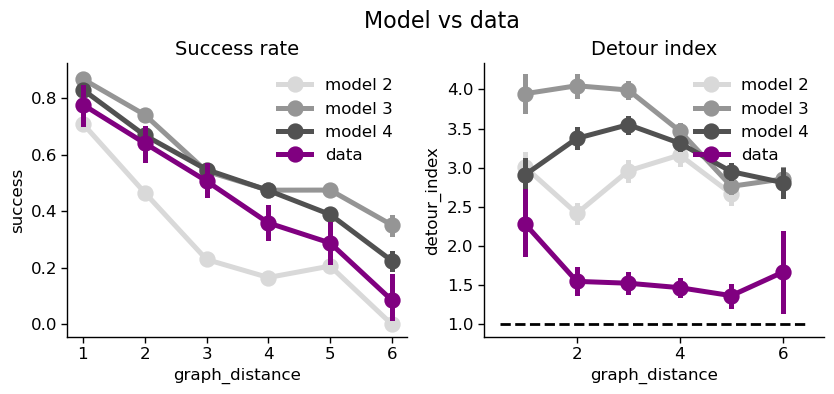

In [191]:
plt.close('all')
colors = sns.color_palette('Greys',3)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.pointplot(data = model2_trial30, x = 'graph_distance', y = 'success', ax = ax[0], native_scale=True, color=colors[0], label='model 2')
sns.pointplot(data = model3_trial30, x = 'graph_distance', y = 'success', ax = ax[0], native_scale=True, color=colors[1], label='model 3')
sns.pointplot(data = model4_trial30, x = 'graph_distance', y = 'success', ax = ax[0], native_scale=True, color=colors[2], label='model 4')
sns.pointplot(data = nav_trial, x = 'graph_distance', y = 'success', ax = ax[0], native_scale=True, color='purple', label='data')
ax[0].set_title('Success rate', fontsize=14)

sns.pointplot(data = model2_trial30[model2_trial30.success==1], x = 'graph_distance', y = 'detour_index', ax = ax[1], native_scale=True, color=colors[0], label='model 2')
sns.pointplot(data = model3_trial30[model3_trial30.success==1], x = 'graph_distance', y = 'detour_index', ax = ax[1], native_scale=True, color=colors[1], label='model 3')
sns.pointplot(data = model4_trial30[model4_trial30.success==1], x = 'graph_distance', y = 'detour_index', ax = ax[1], native_scale=True, color=colors[2], label='model 4')
sns.pointplot(data = nav_trial[nav_trial.success==1], x = 'graph_distance', y = 'detour_index', ax = ax[1], native_scale=True, color='purple', label='data')
ax[1].set_title('Detour index', fontsize=14)
ax[1].plot([0.5,6.5],[1,1],'k--')

sns.despine()

fig.tight_layout(rect=[0.05, 0, 0.9, 0.95])
fig.suptitle('Model vs data', fontsize=16)
plt.savefig('Model vs data cutoff 30.png')

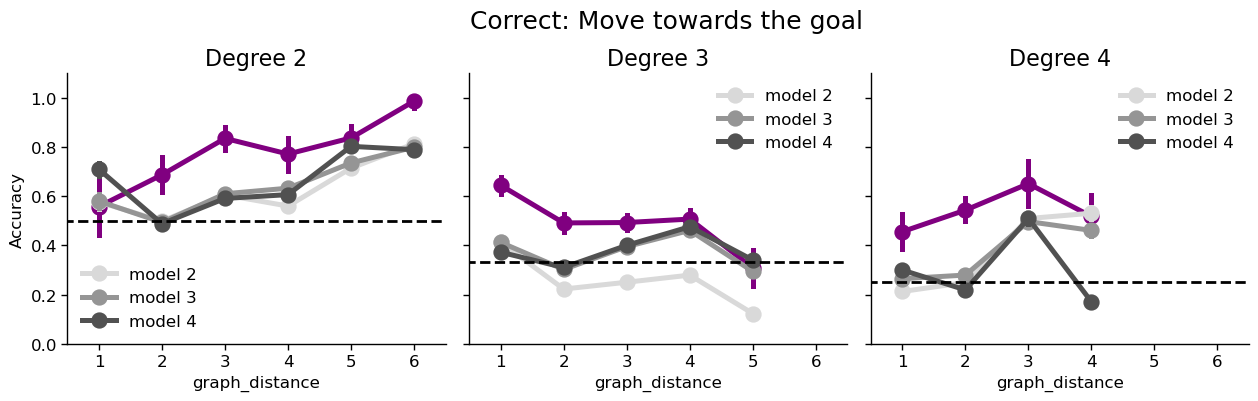

In [205]:
plt.close('all')
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
colors = sns.color_palette('Greys',3)

for dd in range(3):
    ax = axes[dd]
    sns.pointplot(data=nav[(nav.graph_distance>0) & (nav.degree==dd+2)],x='graph_distance',y='room_accuracy',native_scale=True,ax=ax,color='purple')
    # sns.pointplot(data = model2_room30[(model2_room30.graph_distance>0) & (model2_room30.degree==dd+2)].reset_index(), x = 'graph_distance', y = 'room_accuracy', ax = ax, native_scale=True, color=colors[0], label='model 2')
    # sns.pointplot(data = model3_room30[(model3_room30.graph_distance>0) & (model3_room30.degree==dd+2)].reset_index(), x = 'graph_distance', y = 'room_accuracy', ax = ax, native_scale=True, color=colors[1], label='model 3')
    # sns.pointplot(data = model4_room30[(model4_room30.graph_distance>0) & (model4_room30.degree==dd+2)].reset_index(), x = 'graph_distance', y = 'room_accuracy', ax = ax, native_scale=True, color=colors[2], label='model 4')
    sns.pointplot(data = model2_room[(model2_room.graph_distance>0) & (model2_room.degree==dd+2)].reset_index(), x = 'graph_distance', y = 'room_accuracy', ax = ax, native_scale=True, color=colors[0], label='model 2')
    sns.pointplot(data = model3_room[(model3_room.graph_distance>0) & (model3_room.degree==dd+2)].reset_index(), x = 'graph_distance', y = 'room_accuracy', ax = ax, native_scale=True, color=colors[1], label='model 3')
    sns.pointplot(data = model4_room[(model4_room.graph_distance>0) & (model4_room.degree==dd+2)].reset_index(), x = 'graph_distance', y = 'room_accuracy', ax = ax, native_scale=True, color=colors[2], label='model 4')
    ax.plot([-0.5,6.5],[1/(dd+2),1/(dd+2)],'k--')
    ax.set_ylim([0,1.1])
    ax.set_xlim([0.5,6.5])
    ax.set_title(f'Degree {dd+2}',fontsize=16)

    if dd==0:
        ax.set_ylabel('Accuracy')
        
sns.despine()
fig.tight_layout(rect=[0.05, 0, 0.9, 0.95])
plt.suptitle('Correct: Move towards the goal',fontsize=18, y=1)
plt.savefig('Model vs Data Room accuracy.png')

In [221]:
model2_trial['correctTrialsInBlock'] = model2_trial['success'].groupby([model2_trial['Session'],model2_trial['BlockNumber'],model2_trial['nrep']]).cumsum()
model3_trial['correctTrialsInBlock'] = model3_trial['success'].groupby([model3_trial['Session'],model3_trial['BlockNumber'],model3_trial['nrep']]).cumsum()
model4_trial['correctTrialsInBlock'] = model4_trial['success'].groupby([model4_trial['Session'],model4_trial['BlockNumber'],model4_trial['nrep']]).cumsum()

In [229]:
model2_trial30['correctTrialsInBlock'] = model2_trial30['success'].groupby([model2_trial30['Session'],model2_trial30['BlockNumber'],model2_trial30['nrep']]).cumsum()
model3_trial30['correctTrialsInBlock'] = model3_trial30['success'].groupby([model3_trial30['Session'],model3_trial30['BlockNumber'],model3_trial30['nrep']]).cumsum()
model4_trial30['correctTrialsInBlock'] = model4_trial30['success'].groupby([model4_trial30['Session'],model4_trial30['BlockNumber'],model4_trial30['nrep']]).cumsum()

In [445]:
nav_trial.query('EngagedTrialsInBlock<10').success.mean()

np.float64(0.5104895104895105)

Text(0.5, 1, 'Learning in a block')

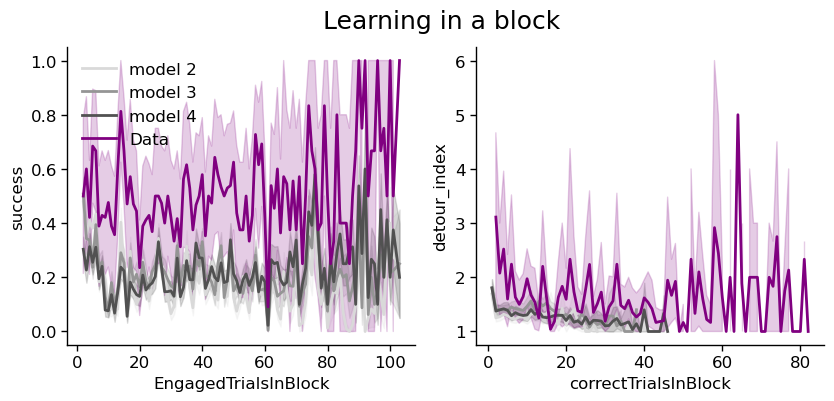

In [446]:
plt.close('all')
fig, axes = plt.subplots(1,2,figsize=(10,4))
colors = sns.color_palette('Greys',3)

sns.lineplot(data=model2_trial,x='EngagedTrialsInBlock',y='success', ax=axes[0],label='model 2',color=colors[0])
sns.lineplot(data=model2_trial.query('success'),x='correctTrialsInBlock',y='detour_index', ax=axes[1],color=colors[0])    

sns.lineplot(data=model3_trial,x='EngagedTrialsInBlock',y='success', ax=axes[0],label='model 3',color=colors[1])
sns.lineplot(data=model3_trial.query('success'),x='correctTrialsInBlock',y='detour_index', ax=axes[1],color=colors[1])    

sns.lineplot(data=model4_trial,x='EngagedTrialsInBlock',y='success', ax=axes[0],label='model 4',color=colors[2])
sns.lineplot(data=model4_trial.query('success'),x='correctTrialsInBlock',y='detour_index', ax=axes[1],color=colors[2])     

sns.lineplot(data=nav_trial,x='EngagedTrialsInBlock',y='success', ax=axes[0],label='Data',color='purple')
sns.lineplot(data=nav_trial.query('success'),x='correctTrialsInBlock',y='detour_index', ax=axes[1],color='purple')  

sns.despine()

fig.tight_layout(rect=[0.05, 0, 0.9, 0.95])
plt.suptitle('Learning in a block',fontsize=18, y=1)
# plt.savefig('Model vs Data Learning cutoff trial specific.png')

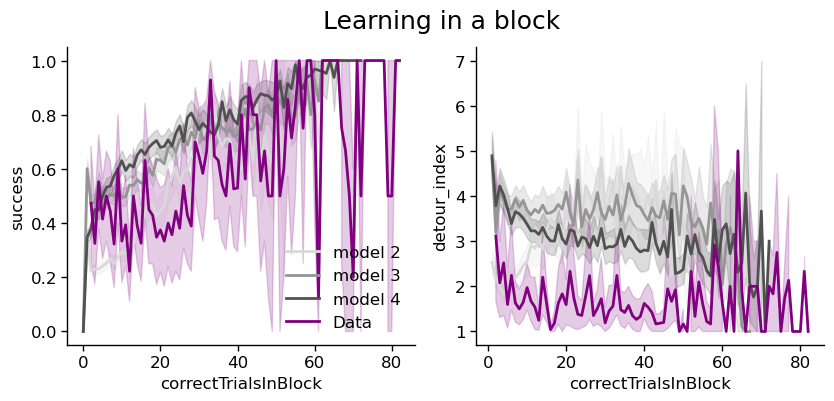

In [230]:
plt.close('all')
fig, axes = plt.subplots(1,2,figsize=(10,4))
colors = sns.color_palette('Greys',3)

sns.lineplot(data=model2_trial30,x='correctTrialsInBlock',y='success', ax=axes[0],label='model 2',color=colors[0])
sns.lineplot(data=model2_trial30.query('success'),x='correctTrialsInBlock',y='detour_index', ax=axes[1],color=colors[0])    

sns.lineplot(data=model3_trial30,x='correctTrialsInBlock',y='success', ax=axes[0],label='model 3',color=colors[1])
sns.lineplot(data=model3_trial30.query('success'),x='correctTrialsInBlock',y='detour_index', ax=axes[1],color=colors[1])    

sns.lineplot(data=model4_trial30,x='correctTrialsInBlock',y='success', ax=axes[0],label='model 4',color=colors[2])
sns.lineplot(data=model4_trial30.query('success'),x='correctTrialsInBlock',y='detour_index', ax=axes[1],color=colors[2])     

sns.lineplot(data=nav_trial,x='correctTrialsInBlock',y='success', ax=axes[0],label='Data',color='purple')
sns.lineplot(data=nav_trial.query('success'),x='correctTrialsInBlock',y='detour_index', ax=axes[1],color='purple')  

sns.despine()

fig.tight_layout(rect=[0.05, 0, 0.9, 0.95])
plt.suptitle('Learning in a block',fontsize=18, y=1)
plt.savefig('Model vs Data Learning cutoff 30.png')

In [174]:
def get_room_accuracy(df):
    delta_dis = df.graph_distance.diff().values[1:]
    delta_dis = np.append(delta_dis,np.nan)
    df['room_accuracy'] = delta_dis==-1
    df.loc[df.minus_step==0,'room_accuracy'] = np.nan
    return df

C:\Users\Admin\AppData\Local\Temp\ipykernel_23468\1493965656.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[df.minus_step==0,'room_accuracy'] = np.nan
C:\Users\Admin\AppData\Local\Temp\ipykernel_23468\1493965656.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[df.minus_step==0,'room_accuracy'] = np.nan
C:\Users\Admin\AppData\Local\Temp\ipykernel_23468\1493965656.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[df.minus_step==0,'room_acc

Text(0.5, 1, 'Correct: Move towards the goal')

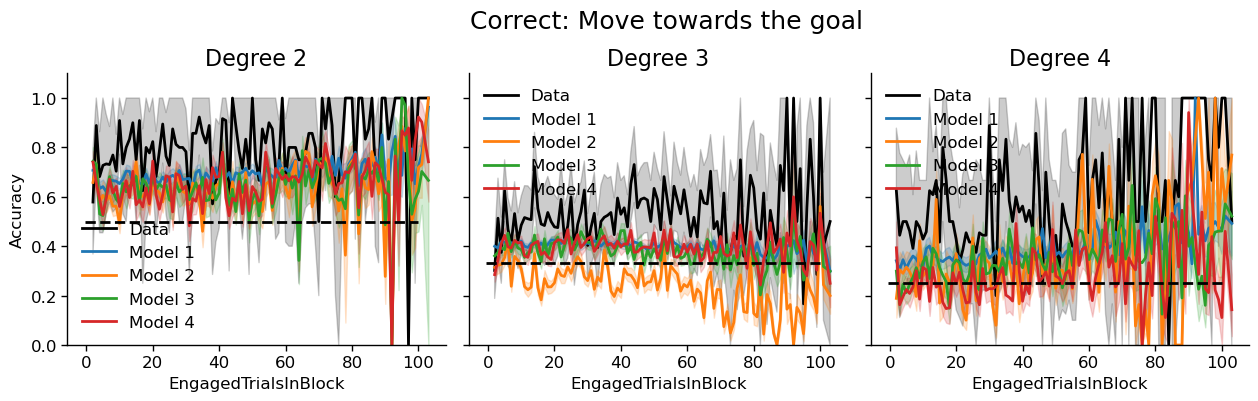

In [451]:
plt.close('all')
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for dd in range(3):
    ax = axes[dd]
    
    a = nav.copy()
    sns.lineplot(data=a[(a.graph_distance>0) & (a.degree==dd+2)],x='EngagedTrialsInBlock',y='room_accuracy',ax=ax,label='Data',color='k')

    a = get_room_accuracy(model1_room30).reset_index(drop=True)
    sns.lineplot(data=a[(a.graph_distance>0) & (a.degree==dd+2)],x='EngagedTrialsInBlock',y='room_accuracy',ax=ax,label='Model 1')
    
    a = get_room_accuracy(model2_room).reset_index(drop=True)
    sns.lineplot(data=a[(a.graph_distance>0) & (a.degree==dd+2)],x='EngagedTrialsInBlock',y='room_accuracy',ax=ax,label='Model 2')

    a = get_room_accuracy(model3_room).reset_index(drop=True)
    sns.lineplot(data=a[(a.graph_distance>0) & (a.degree==dd+2)],x='EngagedTrialsInBlock',y='room_accuracy',ax=ax,label='Model 3')

    a = get_room_accuracy(model4_room).reset_index(drop=True)
    sns.lineplot(data=a[(a.graph_distance>0) & (a.degree==dd+2)],x='EngagedTrialsInBlock',y='room_accuracy',ax=ax,label='Model 4')

    ax.plot([-0.5,100],[1/(dd+2),1/(dd+2)],'k--')
    ax.set_ylim([0,1.1])
    # ax.set_xlim([0.5,6.5])
    ax.set_title(f'Degree {dd+2}',fontsize=16)

    if dd==0:
        ax.set_ylabel('Accuracy')
        
sns.despine()
fig.tight_layout(rect=[0.05, 0, 0.9, 0.95])
plt.suptitle('Correct: Move towards the goal',fontsize=18, y=1)
# plt.savefig('Room accuracy learning cutoff trial specific.png')

C:\Users\Admin\AppData\Local\Temp\ipykernel_23468\1493965656.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[df.minus_step==0,'room_accuracy'] = np.nan
C:\Users\Admin\AppData\Local\Temp\ipykernel_23468\1493965656.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[df.minus_step==0,'room_accuracy'] = np.nan
C:\Users\Admin\AppData\Local\Temp\ipykernel_23468\1493965656.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[df.minus_step==0,'room_acc

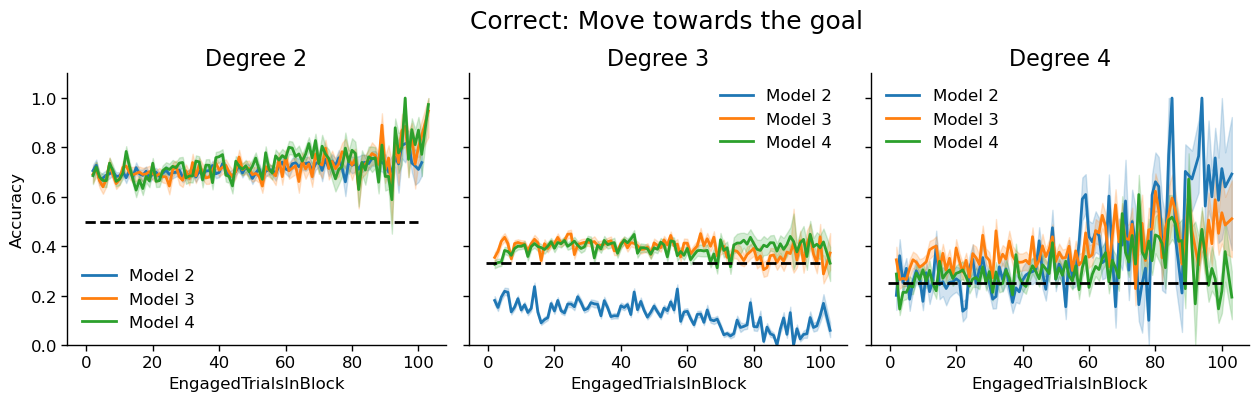

In [193]:
plt.close('all')
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for dd in range(3):
    ax = axes[dd]
    
    a = get_room_accuracy(model2_room30).reset_index(drop=True)
    sns.lineplot(data=a[(a.graph_distance>0) & (a.degree==dd+2)],x='EngagedTrialsInBlock',y='room_accuracy',ax=ax,label='Model 2')

    a = get_room_accuracy(model3_room30).reset_index(drop=True)
    sns.lineplot(data=a[(a.graph_distance>0) & (a.degree==dd+2)],x='EngagedTrialsInBlock',y='room_accuracy',ax=ax,label='Model 3')

    a = get_room_accuracy(model4_room30).reset_index(drop=True)
    sns.lineplot(data=a[(a.graph_distance>0) & (a.degree==dd+2)],x='EngagedTrialsInBlock',y='room_accuracy',ax=ax,label='Model 4')

    ax.plot([-0.5,100],[1/(dd+2),1/(dd+2)],'k--')
    ax.set_ylim([0,1.1])
    # ax.set_xlim([0.5,6.5])
    ax.set_title(f'Degree {dd+2}',fontsize=16)

    if dd==0:
        ax.set_ylabel('Accuracy')
        
sns.despine()
fig.tight_layout(rect=[0.05, 0, 0.9, 0.95])
plt.suptitle('Correct: Move towards the goal',fontsize=18, y=1)
plt.savefig('Room accuracy learning cutoff 30.png')

#### visualize in graph

In [339]:
def visualize_by_target(df,metric,ax,title,cmap,vrange):
    
    target_mean = df.groupby(['target']).mean().reset_index()
    df = target_mean.assign(row=lambda x: x.target//4,
                            col=lambda x: x.target%4)
    grid = df.pivot(index='row', columns='col', values=metric) 
    labels = df.pivot(index='row', columns='col', values='target')
    
    if metric=='success':
        annot  = 'T' + labels.astype(str) + '\n' + (100*grid).map('{:.1f}%'.format)
    else:
        annot  = 'T' + labels.astype(str) + '\n' + grid.map('{:.2f}'.format)
        
    sns.heatmap(grid, cmap=cmap, vmin = vrange[0], vmax = vrange[1],
                annot=annot, fmt='',
                square=True, linewidths=2, linecolor='white',
                annot_kws={'fontsize':11,'fontweight':'bold'},
                cbar_kws={'shrink':0.8,'label':'Success'},
                xticklabels=False, yticklabels=False, ax=ax)
    
    ax.set(title=title, xlabel='', ylabel='')
    ax.invert_yaxis()


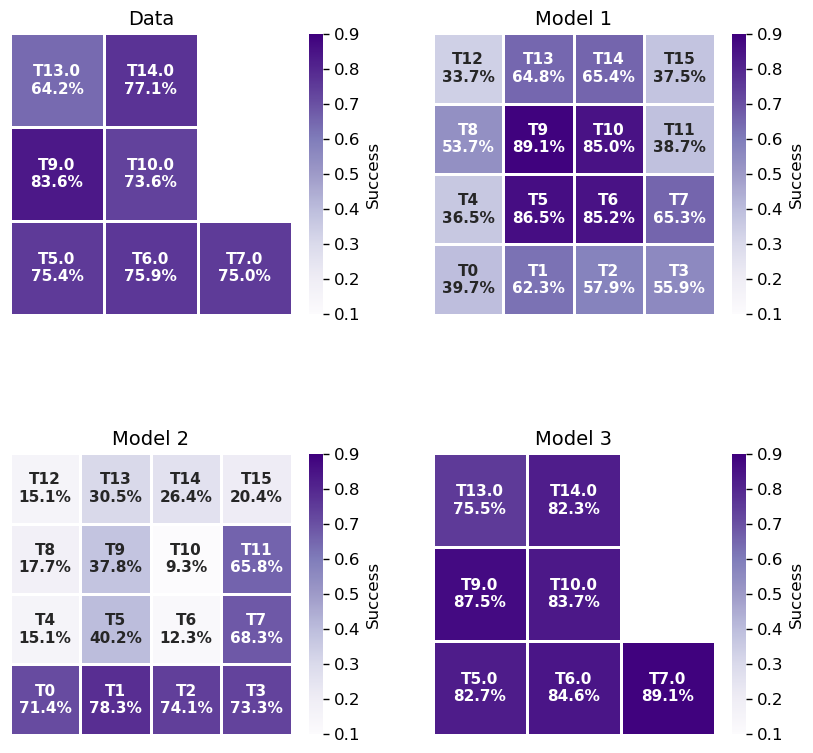

In [335]:
metric = 'success'
titles = ['Data','Model 1','Model 2','Model 3']
dfs = [nav_trial,model1_df,model2_df,model3_df]

plt.close('all')
fig, axes = plt.subplots(2,2,figsize=(10,10))

for ii in range(2):
    for jj in range(2):
        ax = axes[ii,jj]
        idx = ii*2+jj
        visualize_by_target(dfs[idx],metric,axes[ii,jj],titles[idx],'Purples',[0.1,0.9])

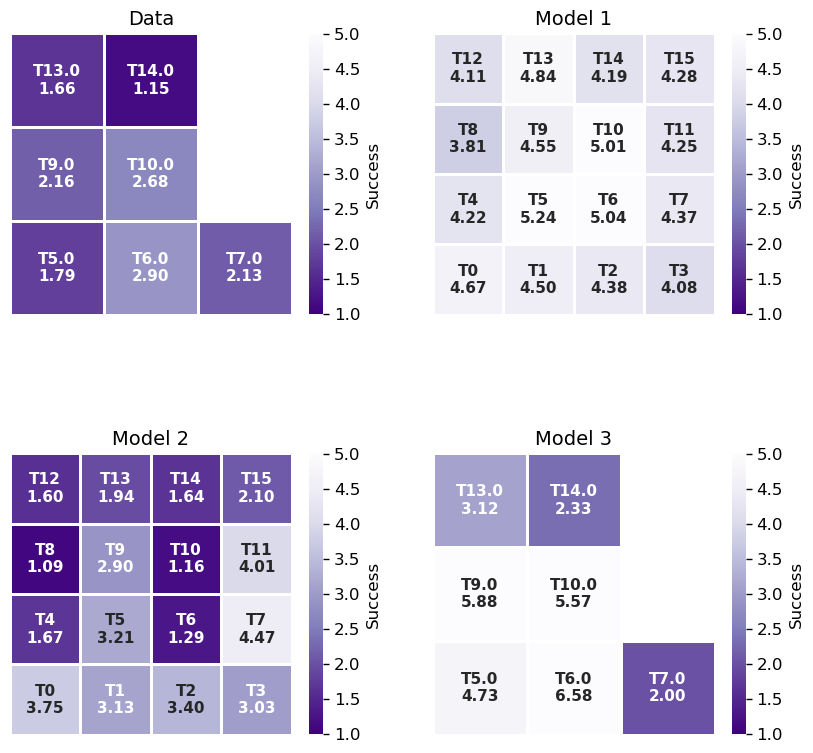

In [340]:
metric = 'detour_index'
titles = ['Data','Model 1','Model 2','Model 3']
dfs = [nav_trial.query('success==1'),model1_df.query('success==1'),model2_df.query('success==1'),model3_df.query('success==1')]

plt.close('all')
fig, axes = plt.subplots(2,2,figsize=(10,10))

for ii in range(2):
    for jj in range(2):
        ax = axes[ii,jj]
        idx = ii*2+jj
        visualize_by_target(dfs[idx],metric,axes[ii,jj],titles[idx],'Purples_r',[1,5])

In [27]:
condition_mean = all_null.groupby(['target','start','model']).mean().reset_index()

<Axes: xlabel='model1', ylabel='model2'>

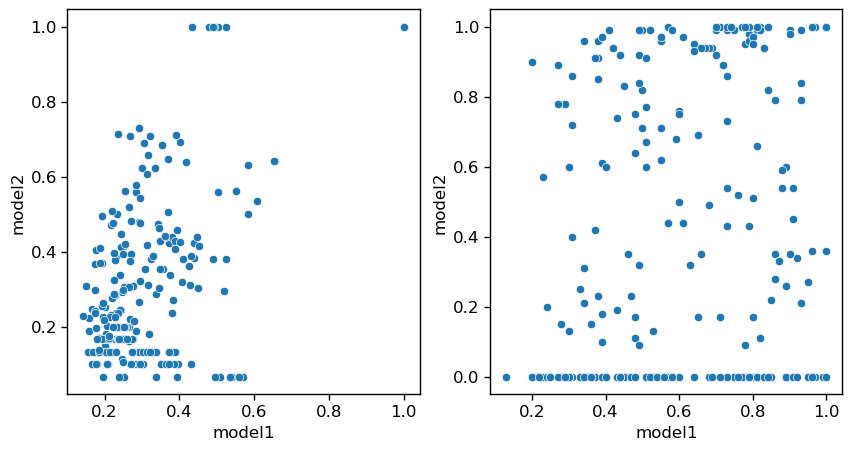

In [34]:
plt.close('all')
fig, axes = plt.subplots(1,2,figsize=(10, 5))

ax = axes[0]
df_plot = condition_mean.pivot_table(
    index=['target', 'start'],
    columns='model',
    values='optimality'
).reset_index()

df_plot = df_plot.rename(columns={1: 'model1', 2: 'model2'})

sns.scatterplot(
    data=df_plot,
    x='model1',
    y='model2',
    ax = ax
)


ax = axes[1]
df_plot = condition_mean.pivot_table(
    index=['target', 'start'],
    columns='model',
    values='success'
).reset_index()

df_plot = df_plot.rename(columns={1: 'model1', 2: 'model2'})

sns.scatterplot(
    data=df_plot,
    x='model1',
    y='model2',
    ax = ax
)

In [ ]:
### add learning curve within a block

#### Visualization of graph

In [398]:
# Action colors
ACTION_COLORS = {
    0: "#FF6B6B",   # Up    – vivid coral
    1: "#4DABF7",   # Right – bright sky blue
    2: "#51CF66",   # Down  – fresh green
    3: "#FFD43B",   # Left  – warm yellow
}

def plot_transition_grid(env, show_self_loops=True):

    SIZE = env.size
    T = env.T
    # GOAL = env.goal
    ACTIONS = ['Left','Right','Up','Down']

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(-0.5, SIZE - 0.5)
    ax.set_ylim(-0.5, SIZE - 0.5)
    ax.set_aspect("equal")
    ax.axis("off")
    fig.patch.set_facecolor("#1A1A2E")
    ax.set_facecolor("#1A1A2E")

    # ── Draw cells ───────────────────────────
    for s in range(SIZE**2):
        r, c = divmod(s, SIZE)
        # flip row so row-0 is at the top
        y = r

        # if s == GOAL:
        #     face, edge, lbl_col = "#2A6F2A", "#6ABF69", "#AADDAA"
        #     label = f"{s}\nGOAL"
        # else:
        face, edge, lbl_col = "#22304A", "#5A6C8C", "#D7E3FC"
        label = str(s)

        rect = mpatches.FancyBboxPatch(
            (c - 0.45, y - 0.45), 0.9, 0.9,
            boxstyle="round,pad=0.04",
            linewidth=1.5,
            edgecolor=edge,
            facecolor=face,
            zorder=2,
        )
        ax.add_patch(rect)
        ax.text(c, y, label, ha="center", va="center",
                fontsize=9, color=lbl_col, fontweight="bold",
                fontfamily="monospace", zorder=3)

    # ── Draw arrows ──────────────────────────
    # arrow_offset: nudge parallel arrows so they don't overlap
    offsets = {0: (-0.07, 0), 1: (0, 0.07), 2: (0.07, 0), 3: (0, -0.07)}

    for s in range(SIZE**2):

        r0, c0 = divmod(s, SIZE)
        y0 = r0

        for a in range(4):
            for s2 in range(SIZE**2):
                prob = T[s, a, s2]
                if prob == 0:
                    continue
                if s2 == s and not show_self_loops:
                    continue

                r1, c1 = divmod(s2, SIZE)
                y1 = r1

                ox, oy = offsets[a]
                x_start, y_start = c0 + ox, y0 + oy
                x_end,   y_end   = c1 + ox, y1 + oy

                # Don't draw zero-length arrows
                if (x_start, y_start) == (x_end, y_end):
                    continue

                color  = ACTION_COLORS[a]
                lw     = 1.0 + prob * 2.5   # thicker = higher probability
                alpha  = 0.5 + prob * 0.5

                ax.annotate(
                    "",
                    xy     =(x_end,   y_end),
                    xytext =(x_start, y_start),
                    arrowprops=dict(
                        arrowstyle="-|>",
                        color=color,
                        lw=lw,
                        alpha=alpha,
                        mutation_scale=12,
                        shrinkA=18, shrinkB=18,
                    ),
                    zorder=4,
                )

    # ── Legend ───────────────────────────────
    handles = [
        mpatches.Patch(color=ACTION_COLORS[a], label=f"Action {a}: {ACTIONS[a]}")
        for a in range(4)
    ]
    # handles += [
    #     mpatches.Patch(color="#6ABF69", label="Goal  (+10)")
    # ]
    leg = ax.legend(
        handles=handles,
        loc="upper left",
        bbox_to_anchor=(1.01, 1),
        frameon=True,
        framealpha=0.15,
        # facecolor="#22304A",
        # edgecolor="#5A6C8C",
        fontsize=9,
        labelcolor="white",
        title="Legend",
        title_fontsize=10,
    )
    leg.get_title().set_color("#8899BB")

    ax.set_title(
        "4×4 Grid World — Transition Matrix",
        color="white", fontsize=13, fontweight="bold",
        pad=14, fontfamily="monospace",
    )

    plt.tight_layout()
    return fig


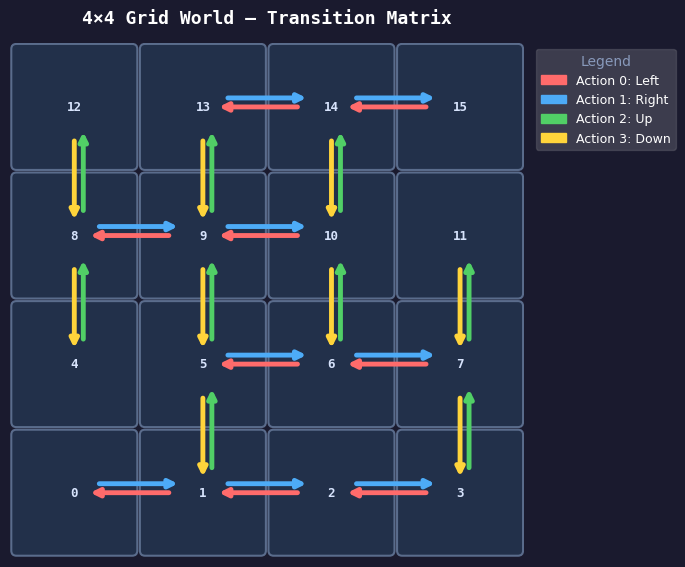

In [399]:
env = NewWorldEnv()
fig = plot_transition_grid(env)
fig.savefig('Grid.png')

In [ ]:
# what does the eye likely doing

# when there are targets on the screen

# when there are no targets on the screen

# searching for targets